<div class="alert alert-block alert-info">
<center><strong> Predicting Urban vs. Rural Household Classification using Supervised Machine Learning </strong></center>
</div>

<hr/>
<center> A major course output (MCO) in completing 20% of final grade in Advanced Intelligent Systems (STINTSY) </center> 

Term 2 A.Y. 2025-2026
<br/>
**Group #2 CSINTSY Survivors (Section S18)**

| Member Name | Contributions |
| ----- | -----  |
| Chavez, Allen Visagar | EDA, Data Preprocessing, Random Forest Classifier |
| Llanes, Andre Gabriel De Ocampo  | EDA, Binomial Logistic Regression, Poster |
| Rojo, Von Matthew De Guzman *(leader)* | Data Preparation, EDA, Gradient Boosting Classifier, Model Comparison |
| Tan, Jeremy James Teves | Data Preprocessing, Multi-Layer Perceptron, Model Comparison |

Professor: Antioquia, Arren Matthew Capuchino

**Project Objective:** The primary objective of this project is to develop and evaluate supervised machine learning models capable of predicting whether a family resides in an Urban or Rural area (URB). This project utilizes a comprehensive set of socioeconomic and structural features from the **Family Income and Expenditure Survey (FIES) dataset**.
<br/>

**Methodology:** As part of the STINTSY Major Course Output (MCO), we will perform end-to-end machine learning pipeline development, starting with Data Preparation and Exploratory Data Analysis (EDA). Ultimately, we will implement and compare the performance of four supervised machine learning models, **three classical machine learning models and one neural network**, to determine the most effective approach for this classification task.
<hr/>

In [100]:
## Import necessary libraries
import matplotlib.pyplot as plt
import numpy as np # for importing datasets
import math
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

%load_ext autoreload
%autoreload 2
from MCO_functions import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# **[1]** Data Preparation
**Dataset Name:** Family Income and Expenditure Survey 2012 Vol 1
<br/>
**Accessed from:** [click this link](https://psada.psa.gov.ph/catalog/38/data-dictionary/F2?file_name=fies2012_v1)

In [101]:
csv_path = 'feis_dataset/FIES PUF 2012 Vol.1.CSV'
csvdict_path = 'feis_dataset/fies_2012_v1_metadata(dictionary)'
fies_original_df = pd.read_csv(csv_path)

fies_original_df

,W_REGN,W_OID,W_SHSN,W_HCN,URB,RSTR,PSU,BWEIGHT,RFACT,FSIZE,...,PC_QTY,OVEN_QTY,MOTOR_BANCA_QTY,MOTORCYCLE_QTY,POP_ADJ,PCINC,NATPC,NATDC,REGDC,REGPC
0,14,101001000,2,25,2,21100,415052,138.25,200.6576,3.0,...,01,01,,,0.946172,108417.00,9,8,8,9
1,14,101001000,3,43,2,21100,415052,138.25,200.6576,12.5,...,,01,,01,0.946172,30631.60,5,9,9,4
2,14,101001000,4,62,2,21100,415052,138.25,200.6576,2.0,...,,01,,,0.946172,86992.50,9,6,6,8
3,14,101001000,5,79,2,21100,415052,138.25,200.6576,4.0,...,,01,,,0.946172,43325.75,6,6,6,6
4,14,101001000,10,165,2,21100,415052,138.25,200.6576,5.0,...,,,,01,0.946172,37481.80,6,6,6,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40166,12,9804029001,18,568,1,22000,114062,271.25,963.2264,5.0,...,00,00,00,00,0.902863,30101.60,5,5,7,7
40167,12,9804035000,1,25,2,22000,414067,271.25,588.6253,9.0,...,00,01,00,00,0.902863,14368.89,1,5,7,3
40168,12,9804035000,2,51,2,22000,414067,271.25,588.6253,6.0,...,00,00,00,00,0.902863,19137.33,3,4,6,4
40169,12,9804035000,3,75,2,22000,414067,271.25,588.6253,5.0,...,00,01,00,00,0.902863,30985.00,5,6,7,7


### Feature Selection (Manual Scoping)

The FIES 2012 dataset contains over 90 columns spanning a wide range of household information. However, not all of these variables are relevant to our classification goal of predicting urban versus rural residence. Including irrelevant or redundant columns, such as survey identifiers (`W_OID`, `W_SHSN`, `W_HCN`), sampling weights (`BWEIGHT`, `RFACT`), and strata markers (`RSTR`, `PSU`), would add noise to our models without contributing any predictive signal.

To scope the dataset down to only the features most likely to differ meaningfully between urban and rural households, we performed a **manual feature selection** based on domain knowledge of the FIES survey. We retained features across four thematic groups:

- **Geographic & Structural Housing** (`W_REGN`, `BLDG_TYPE`, `ROOF`, `WALLS`, `TOILET`, `ELECTRIC`, `WATER`): Region and physical housing characteristics are strong indicators of urban or rural setting.
- **Income & Receipts** (`NET_RECEIPT`, `REGFT`, `EAINC`, `TOINC`): The source and scale of a household's income reflects its economic integration, urban households tend to earn more from formal employment, while rural households derive more from agricultural and subsistence activities.
- **Expenditure** (`T_FOOD_HOME`, `T_FOOD`, `T_CLOTH`, `T_HEALTH`, `T_HOUSING_WATER`, `T_RENTVAL`, `T_IMPUTED_RENT`, `T_COMMUNICATION`, `T_BREAD`, `T_MEAT`, `T_FISH`, `T_MILK`, `T_OIL`, `T_FRUIT`, `T_VEG`, `T_SUGAR`, `T_FOOD_NEC`, `T_COFFEE`, `T_MINERAL`, `T_NFOOD`, `T_TOTEX`, `T_TOTDIS`): Spending patterns reflect lifestyle, cost of living, and access to goods and services, all of which differ substantially between urban and rural areas.
- **Asset Ownership** (`CAR_QTY`, `MOTORCYCLE_QTY`, `PC_QTY`, `LANDLINE_QTY`, `CELLPHONE_QTY`, `TV_QTY`, `RADIO_QTY`, `AIRCON_QTY`, `WASH_QTY`, `REF_QTY`): Ownership of household assets proxies for wealth and access to infrastructure, which are closely tied to urbanization.

This manual scoping reduced the dataset from 90+ columns to **44 features** (including the target variable `URB`), keeping the dataset focused and reducing the risk of the models learning from irrelevant noise.

In [102]:
selected_features = [
    'URB', # Target Variable
    'W_REGN', 'BLDG_TYPE', 'ROOF', 'WALLS', 'TOILET', 'ELECTRIC', 'WATER',
    'NET_RECEIPT', 'REGFT', 'EAINC', 'TOINC', 'T_FOOD_HOME', 'T_FOOD', 
    'T_CLOTH', 'T_HEALTH', 'T_HOUSING_WATER', 'T_RENTVAL', 'T_IMPUTED_RENT', 
    'T_COMMUNICATION', 'T_BREAD', 'T_MEAT', 'T_FISH', 'T_MILK', 'T_OIL', 'T_FRUIT', 
    'T_VEG', 'T_SUGAR', 'T_FOOD_NEC', 'T_COFFEE', 'T_MINERAL', 'T_NFOOD', 
    'T_TOTEX', 'T_TOTDIS', 'CAR_QTY', 'MOTORCYCLE_QTY', 'PC_QTY', 
    'LANDLINE_QTY', 'CELLPHONE_QTY', 'TV_QTY', 'RADIO_QTY', 'AIRCON_QTY', 
    'WASH_QTY', 'REF_QTY'
]

fies_subset_df = fies_original_df[selected_features].copy()
fies_subset_df

,URB,W_REGN,BLDG_TYPE,ROOF,WALLS,TOILET,ELECTRIC,WATER,NET_RECEIPT,REGFT,...,CAR_QTY,MOTORCYCLE_QTY,PC_QTY,LANDLINE_QTY,CELLPHONE_QTY,TV_QTY,RADIO_QTY,AIRCON_QTY,WASH_QTY,REF_QTY
0,2,14,1,1,1,1,1,1,4385,76666,...,,,01,,02,01,01,,01,01
1,2,14,1,5,5,3,1,1,1350,369,...,,01,,,03,01,01,,,
2,2,14,2,1,1,1,1,1,1625,14830,...,01,,,,01,01,01,01,,01
3,2,14,1,1,1,1,1,6,7649,29394,...,,,,,02,01,01,,02,01
4,2,14,1,1,1,1,1,1,7359,130,...,,01,,,01,01,01,,01,01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40166,1,12,1,1,1,1,1,1,0,140,...,00,00,00,00,02,01,01,00,00,00
40167,2,12,1,1,1,0,1,2,0,620,...,00,00,00,00,01,01,00,00,00,00
40168,2,12,1,2,2,0,1,2,1170,540,...,00,00,00,00,01,01,01,00,00,00
40169,2,12,1,1,1,2,1,2,1664,0,...,00,00,00,00,02,01,01,00,00,00


### Data Cleaning: Asset Quantity Columns

Upon initial inspection, the asset quantity columns (`CAR_QTY`, `PC_QTY`, `AIRCON_QTY`, etc.) were found to contain mixed-type entries, some values were stored as strings (e.g., `"01"`, `"00"`) rather than integers. This likely stems from how the raw CSV was encoded during survey digitization. Left uncleaned, these columns would be treated as categorical text rather than numeric counts, causing errors during statistical analysis and model training.

We standardize all quantity columns by stripping whitespace, replacing empty strings with `0`, coercing values to numeric (with unparseable entries becoming `NaN`), filling any remaining `NaN`s with `0`, and casting the entire column to integer type.

In [103]:
qty_columns = [
    'CAR_QTY', 'MOTORCYCLE_QTY', 'PC_QTY', 'LANDLINE_QTY', 
    'CELLPHONE_QTY', 'TV_QTY', 'RADIO_QTY', 'AIRCON_QTY', 
    'WASH_QTY', 'REF_QTY'
]

# Clean and convert the columns
for col in qty_columns:
    # Convert to string, strip whitespace, and replace empty strings with '0'
    fies_subset_df[col] = fies_subset_df[col].astype(str).str.strip().replace('', '0')
    
    # Convert the column to numeric. Any weird unparseable values become NaN (errors='coerce')
    fies_subset_df[col] = pd.to_numeric(fies_subset_df[col], errors='coerce')
    
    # Fill any remaining NaNs with 0, then cast the whole column to integer
    fies_subset_df[col] = fies_subset_df[col].fillna(0).astype(int)

fies_subset_df

,URB,W_REGN,BLDG_TYPE,ROOF,WALLS,TOILET,ELECTRIC,WATER,NET_RECEIPT,REGFT,...,CAR_QTY,MOTORCYCLE_QTY,PC_QTY,LANDLINE_QTY,CELLPHONE_QTY,TV_QTY,RADIO_QTY,AIRCON_QTY,WASH_QTY,REF_QTY
0,2,14,1,1,1,1,1,1,4385,76666,...,0,0,1,0,2,1,1,0,1,1
1,2,14,1,5,5,3,1,1,1350,369,...,0,1,0,0,3,1,1,0,0,0
2,2,14,2,1,1,1,1,1,1625,14830,...,1,0,0,0,1,1,1,1,0,1
3,2,14,1,1,1,1,1,6,7649,29394,...,0,0,0,0,2,1,1,0,2,1
4,2,14,1,1,1,1,1,1,7359,130,...,0,1,0,0,1,1,1,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40166,1,12,1,1,1,1,1,1,0,140,...,0,0,0,0,2,1,1,0,0,0
40167,2,12,1,1,1,0,1,2,0,620,...,0,0,0,0,1,1,0,0,0,0
40168,2,12,1,2,2,0,1,2,1170,540,...,0,0,0,0,1,1,1,0,0,0
40169,2,12,1,1,1,2,1,2,1664,0,...,0,0,0,0,2,1,1,0,0,0


### Data Quality Check: Null Values and Whitespaces

Before proceeding with analysis, we verify that the dataset contains no missing values or stray whitespace entries that could silently distort our statistics or model training. We replace any whitespace-only strings with `pd.NA` and then count null values per column.

In [104]:
# check if there is any null values or whitespaces
ws_or_na_df = fies_subset_df.replace(r'^\s*$', pd.NA, regex=True)
ws_or_na_ctr = ws_or_na_df.isna().sum()

print("Whitespaces or null value counts: ")
print(ws_or_na_ctr.to_string())

Whitespaces or null value counts: 
URB                0
W_REGN             0
BLDG_TYPE          0
ROOF               0
WALLS              0
TOILET             0
ELECTRIC           0
WATER              0
NET_RECEIPT        0
REGFT              0
EAINC              0
TOINC              0
T_FOOD_HOME        0
T_FOOD             0
T_CLOTH            0
T_HEALTH           0
T_HOUSING_WATER    0
T_RENTVAL          0
T_IMPUTED_RENT     0
T_COMMUNICATION    0
T_BREAD            0
T_MEAT             0
T_FISH             0
T_MILK             0
T_OIL              0
T_FRUIT            0
T_VEG              0
T_SUGAR            0
T_FOOD_NEC         0
T_COFFEE           0
T_MINERAL          0
T_NFOOD            0
T_TOTEX            0
T_TOTDIS           0
CAR_QTY            0
MOTORCYCLE_QTY     0
PC_QTY             0
LANDLINE_QTY       0
CELLPHONE_QTY      0
TV_QTY             0
RADIO_QTY          0
AIRCON_QTY         0
WASH_QTY           0
REF_QTY            0


### Data Quality Check: Duplicate Rows

We also check for exact duplicate rows in the dataset. Duplicate survey entries, if present, could artificially inflate the representation of certain households and bias both our EDA statistics and model training.

In [105]:
# check if there are any duplicates
dupes = fies_subset_df.duplicated().sum()

if (dupes <= 0):
  print('There are no duplicates')
else:
  print('There are', dupes, 'duplicates')

There are no duplicates


# **[2]** Exploratory Data Analysis (EDA)
Before building our machine learning models, we explore the dataset to understand its structure, distributions, and the key differences between urban and rural households. This phase serves two purposes: to verify data quality and to develop intuitions about which features are likely to be the most predictive.

Our EDA is organized into three parts:
1. **Basic Dataset Information** — summary statistics across all features
2. **Urban and Rural Comparative Statistics** — side-by-side analysis of income, expenditure, regional distribution, structural housing, amenities, and asset ownership between the two classes
3. **Household Composition** — deeper breakdown of physical housing characteristics and asset distributions across the full dataset

# **[2.1]** Basic Dataset Information
We begin with a broad statistical summary of all features in our working dataset. This gives us a baseline understanding of each feature's range, central tendency, and spread, and helps flag any columns with suspicious distributions (e.g., features with a `max` far exceeding the `75th percentile`, indicating extreme outliers in financial columns).

In [106]:
# summary for all columns
description = fies_subset_df.describe().T
print(description.to_string())

                   count           mean            std     min      25%       50%       75%         max
URB              40171.0       1.617311       0.486049     1.0      1.0       2.0       2.0         2.0
W_REGN           40171.0      13.019890      11.995555     1.0      6.0      10.0      14.0        42.0
BLDG_TYPE        40171.0       1.087949       0.388863     1.0      1.0       1.0       1.0         6.0
ROOF             40171.0       1.377760       0.894712     1.0      1.0       1.0       1.0         7.0
WALLS            40171.0       1.641607       1.125698     1.0      1.0       1.0       2.0         7.0
TOILET           40171.0       1.718130       1.539145     0.0      1.0       1.0       2.0         7.0
ELECTRIC         40171.0       1.131563       0.338019     1.0      1.0       1.0       1.0         2.0
WATER            40171.0       3.186030       2.405758     1.0      1.0       3.0       4.0        12.0
NET_RECEIPT      40171.0    2924.002713    4302.292834     0.0  

The summary output reveals several important observations:

**Class Balance (`URB`):** The dataset contains 40,171 households. With a mean of ~1.62 (where 1 = Urban, 2 = Rural before remapping), the dataset is moderately imbalanced, approximately **38.3% Urban (15,373)** and **61.7% Rural (24,798)**. This imbalance means we should prioritize **Balanced Accuracy** as our evaluation metric rather than raw accuracy, which could be misleading.

**Financial Features (Income & Expenditure):** Financial columns show extreme right skew, the gap between the 75th percentile and the maximum is enormous. For example, `TOINC` has a median of ₱140,125 but a maximum of ₱8,652,144, and `T_NFOOD` has a median of ₱55,147 but a maximum of ₱2,470,903. The standard deviations on financial columns frequently exceed their means, confirming severe outliers from high-income households. This justifies the log transformation applied during preprocessing.

**Asset Ownership:** The asset columns (`CAR_QTY`, `PC_QTY`, `AIRCON_QTY`, `LANDLINE_QTY`) have medians of 0 and 75th percentiles of 0, meaning the majority of households own none of these items. The exception is `CELLPHONE_QTY`, which has a median of 1 and a mean of ~1.71, reflecting the widespread mobile phone penetration in the Philippines even in 2012. `TV_QTY` also has a median of 1, indicating televisions are common across both classes.

**Categorical Features:** Features like `BLDG_TYPE`, `ROOF`, and `WALLS` show very low means (close to 1) with small standard deviations, indicating that the majority of responses cluster around category 1 (Single House, Strong Roof, Strong Walls). Categories 3–6 are rare, which will be important to consider when interpreting per-category model behavior.

# **[2.2]** Urban and Rural Comparative Statistics
With baseline statistics established, we now compare how urban and rural households differ across several key dimensions. These comparisons are central to understanding what makes the classification task learnable, each chart below highlights a distinct signal that our models can exploit.

### **1.) Income and Expenditure Distribution**

We begin by comparing the average monthly expenditure and income profiles of urban and rural households side by side. Urban households are expected to spend and earn more across nearly all categories due to higher costs of living, greater access to goods and services, and more diversified income streams. Rural households, by contrast, tend to have lower absolute expenditure but derive a greater share of their income from agricultural and subsistence activities such as farming, fishing, and livestock raising, captured primarily by `NET_RECEIPT` and `EAINC`.

In [107]:
columns = fies_subset_df.columns

T_columns = [col for col in columns if col.startswith("T_")] # categories

income_prefixes = ("NET_", "REGFT", "EAINC", "TOINC")
NET_columns = [col for col in columns if col.upper().startswith(income_prefixes)] # categories


rural_df =  fies_subset_df[fies_subset_df["URB"] == 2]
urban_df = fies_subset_df[fies_subset_df["URB"] == 1]

# Monthly expenses categories
rural_T_df = rural_df[T_columns]
urban_T_df = urban_df[T_columns]

rural_T_mean_sr = rural_T_df.mean()
urban_T_mean_sr = urban_T_df.mean()

# Income and receipts categories
rural_NET_df = rural_df[NET_columns]
urban_NET_df = urban_df[NET_columns]

rural_NET_mean_sr = rural_NET_df.mean()
urban_NET_mean_sr = urban_NET_df.mean()

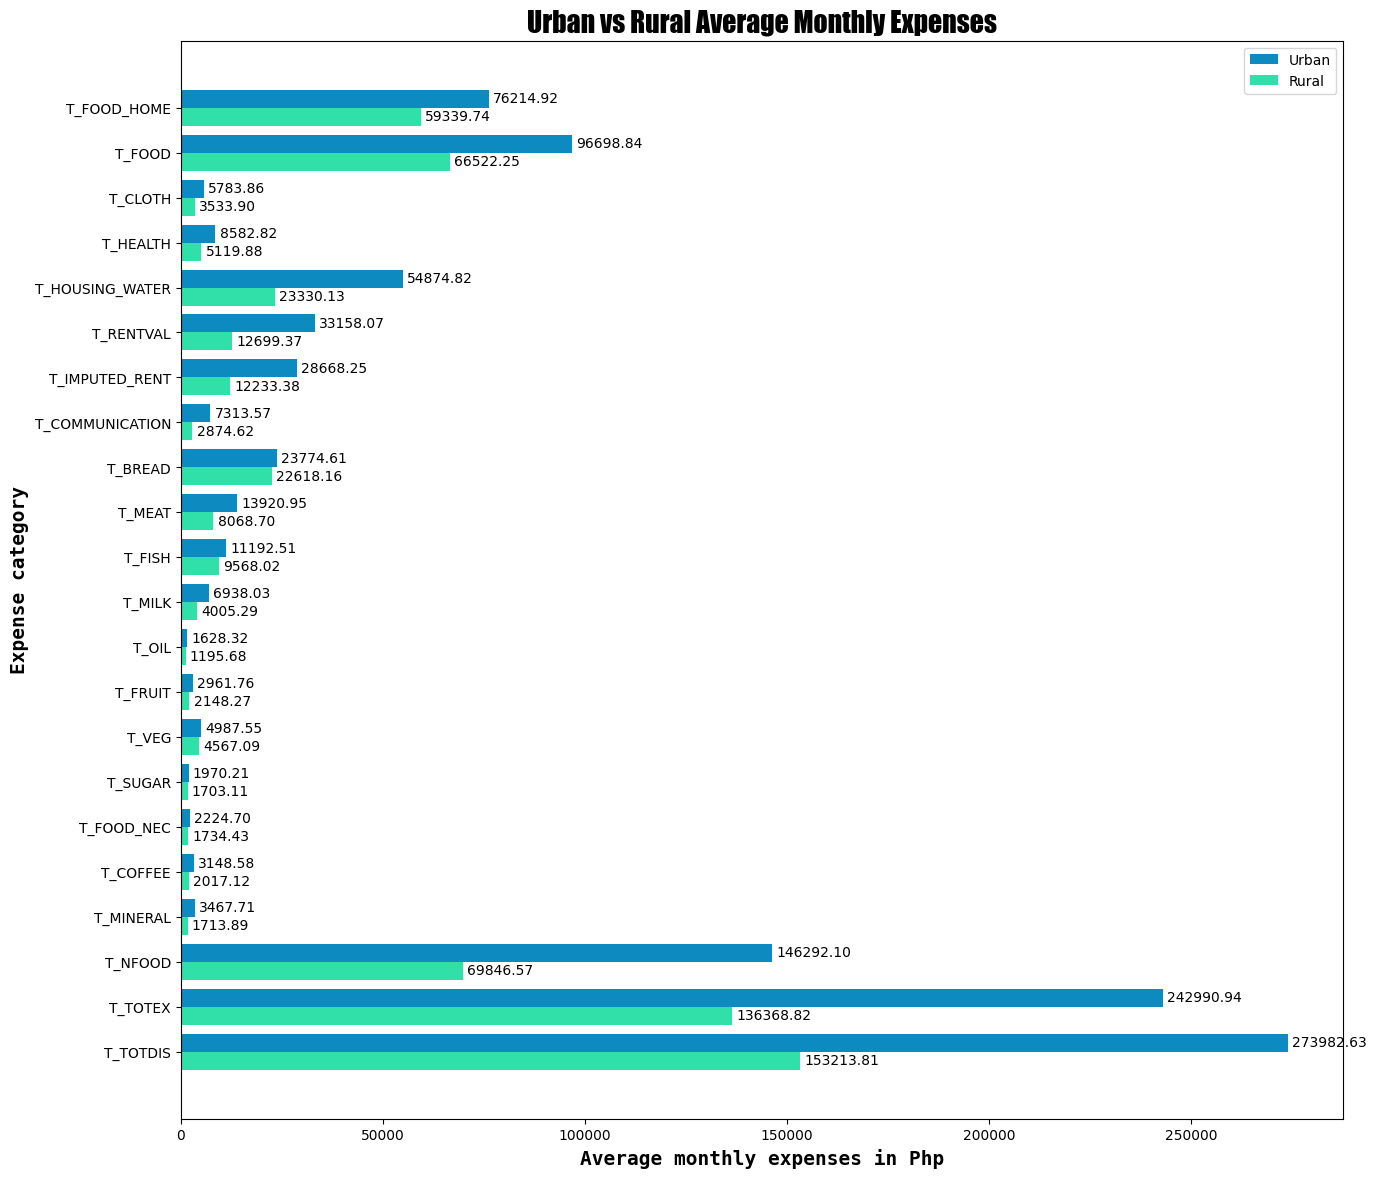

In [108]:
# Compare the average monthly expenses of urban and rural households
compareChart(
    mode="T", # expense
    n=len(T_columns), 
    cat=T_columns, 
    figwidth=15, 
    figheight=14, 
    urban_columns=urban_T_mean_sr.values, 
    rural_columns=rural_T_mean_sr.values, 
    title="Urban vs Rural Average Monthly Expenses"
)

**Urban vs Rural Average Monthly Expenses:**

The expenditure comparison chart reveals a consistent and substantial gap between urban and rural households across nearly all spending categories:

- **`T_HOUSING_WATER`, `T_RENTVAL`, and `T_IMPUTED_RENT`** show the largest absolute differences. Urban households spend dramatically more on housing-related costs, reflecting higher market rents, utility bills, and property values in urban centers. This is the most visually dominant gap in the chart.
- **`T_NFOOD` and `T_TOTEX`** are also considerably higher for urban households, driven by higher non-food costs such as transportation, communication, recreation, and education, all of which are more expensive and more frequently consumed in urban areas.
- **`T_FOOD` and `T_FOOD_HOME`** are higher for urban households in absolute terms, reflecting higher food prices and greater access to commercial food products. However, the relative gap is smaller than for housing and non-food expenditure, suggesting food spending is more uniform across classes.
- **Granular food categories** (`T_MINERAL`, `T_COFFEE`, `T_MEAT`, `T_MILK`) all trend higher for urban households, consistent with greater access to commercial and packaged food products.
- Rural households spend slightly more on `NET_RECEIPT`-related categories and show higher values for subsistence-linked items, which is captured in the income chart below.

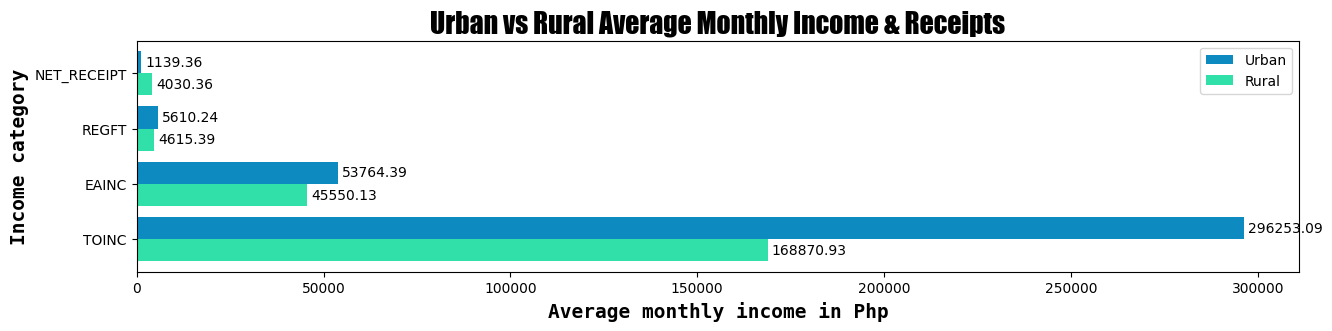

In [109]:
# Compare the average monthly income and receipts of urban and rural households
compareChart(
    mode="N", # income
    n=len(NET_columns), 
    cat=NET_columns, 
    figwidth=15, 
    figheight=3,
    urban_columns=urban_NET_mean_sr.values, 
    rural_columns=rural_NET_mean_sr.values, 
    title="Urban vs Rural Average Monthly Income & Receipts"
)

**Urban vs Rural Average Monthly Income & Receipts:**

- **`TOINC` (Total Income)** is substantially higher for urban households, reflecting the wage premium associated with formal urban employment and proximity to economic centers.
- **`NET_RECEIPT`** is markedly higher for rural households, this is the total net receipt from family sustenance activities (farming, fishing, livestock). This is the single most distinctive rural income signal and explains its dominance in the Random Forest feature importance rankings later.
- **`EAINC` (Entrepreneurial Activities Income)** is similar across both classes but slightly higher for rural households, driven by agricultural enterprise income.
- **`REGFT` (Received Gifts)** is marginally higher for urban households, likely reflecting remittances and cash transfers that are more commonly received by urban relatives of OFW families.

Overall, the income and expenditure profiles confirm that urban and rural households are genuinely distinct in their financial behavior, validating the classification task as a learnable problem.

 ### **2.) Regional Distribution**

 The Philippines is a geographically diverse country where urbanization is not distributed evenly. Metro Manila (NCR) and nearby regions such as CALABARZON are highly urbanized, while regions in Mindanao, the Visayas, and the Cordillera are predominantly rural. We visualize the household count and urban-rural proportion per region to understand the geographic composition of our dataset and to confirm that region is a meaningful predictor of urban or rural classification.

In [110]:

# ── Label mappings ────────────────────────────────────────────────────────────
REGION_LABELS = {
    1:  "Region I\n(Ilocos)",         2:  "Region II\n(Cagayan Valley)",
    3:  "Region III\n(C. Luzon)",     5:  "Region V\n(Bicol)",
    6:  "Region VI\n(W. Visayas)",    7:  "Region VII\n(C. Visayas)",
    8:  "Region VIII\n(E. Visayas)",  9:  "Region IX\n(Zamboanga)",
    10: "Region X\n(N. Mindanao)",    11: "Region XI\n(Davao)",
    12: "Region XII\n(SOCCSKSARGEN)", 13: "NCR",
    14: "CAR",                        15: "ARMM",
    16: "CARAGA",                     41: "Region IVA\n(CALABARZON)",
    42: "Region IVB\n(MIMAROPA)",
}
BLDG_LABELS  = {1:"Single House", 2:"Duplex", 3:"Multi-unit", 4:"Commercial/Industrial", 5:"Makeshift", 6:"Other"}
ROOF_LABELS  = {1:"Strong", 2:"Light", 3:"Salvaged/Makeshift", 4:"Mixed→Strong", 5:"Mixed→Light", 6:"Mixed→Salvaged", 7:"N/A"}
WALLS_LABELS = {1:"Strong", 2:"Light", 3:"Salvaged/Makeshift", 4:"Mixed→Strong", 5:"Mixed→Light", 6:"Mixed→Salvaged", 7:"N/A"}
TOILET_LABELS= {0:"None", 1:"Water-sealed (own)", 2:"Water-sealed (shared)", 3:"WS Other (own)", 4:"WS Other (shared)", 5:"Closed Pit", 6:"Open Pit", 7:"Others"}
ELECTRIC_LABELS = {1:"Yes", 2:"No"}
WATER_LABELS = {
    1:"Comm. Faucet (own)", 2:"Comm. Faucet (shared)", 3:"Deep Well (own)",
    4:"Deep Well (shared)", 5:"Shallow Well", 6:"Dug Well",
    7:"Protected Spring", 8:"Unprotected Spring", 9:"Lake/River/Rain",
    10:"Peddler", 11:"Bottled", 12:"Others"
}

urban_c, rural_c = "#0d8ac0", "#30e0a8"

# Apply readable labels to a working copy
fies_subset_df_labeled = fies_subset_df.copy()
fies_subset_df_labeled["URB_LABEL"]   = fies_subset_df_labeled["URB"].map({1:"Urban", 2:"Rural"})
fies_subset_df_labeled["REGION_LABEL"]= fies_subset_df_labeled["W_REGN"].map(REGION_LABELS)


print("Label mappings ready.")


Label mappings ready.


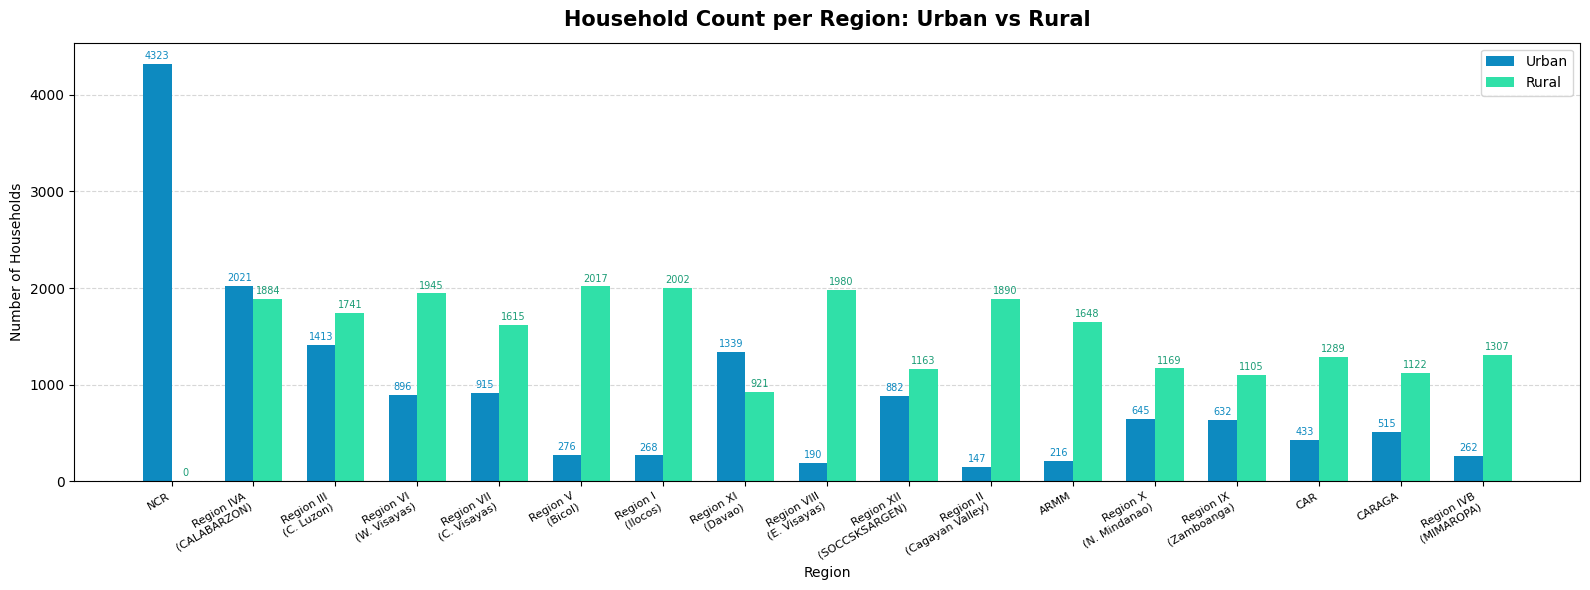

In [111]:

# Regional counts: Urban vs Rural
region_urb = (
    fies_subset_df_labeled
    .groupby(["REGION_LABEL", "URB_LABEL"])
    .size()
    .unstack(fill_value=0)
)

# Ensure both columns exist
for col in ["Urban", "Rural"]:
    if col not in region_urb.columns:
        region_urb[col] = 0

region_urb["Total"] = region_urb["Urban"] + region_urb["Rural"]
region_urb = region_urb.sort_values("Total", ascending=False)

# Plot 1: Grouped bar — raw counts
regions = region_urb.index.tolist()
x       = np.arange(len(regions))
bar_w   = 0.35

fig, ax = plt.subplots(figsize=(16, 6))
b_u = ax.bar(x - bar_w/2, region_urb["Urban"], bar_w, label="Urban", color=urban_c)
b_r = ax.bar(x + bar_w/2, region_urb["Rural"],  bar_w, label="Rural",  color=rural_c)

for bar in b_u:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+30,
            str(int(bar.get_height())), ha="center", va="bottom", fontsize=7, color=urban_c)
for bar in b_r:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+30,
            str(int(bar.get_height())), ha="center", va="bottom", fontsize=7, color="#1a9c75")

ax.set_title("Household Count per Region: Urban vs Rural", fontsize=15, fontweight="bold", pad=12)
ax.set_xticks(x); ax.set_xticklabels(regions, fontsize=8, rotation=30, ha="right")
ax.set_xlabel("Region"); ax.set_ylabel("Number of Households")
ax.yaxis.grid(True, linestyle="--", alpha=0.5); ax.set_axisbelow(True)
ax.legend()
plt.tight_layout(); plt.show()


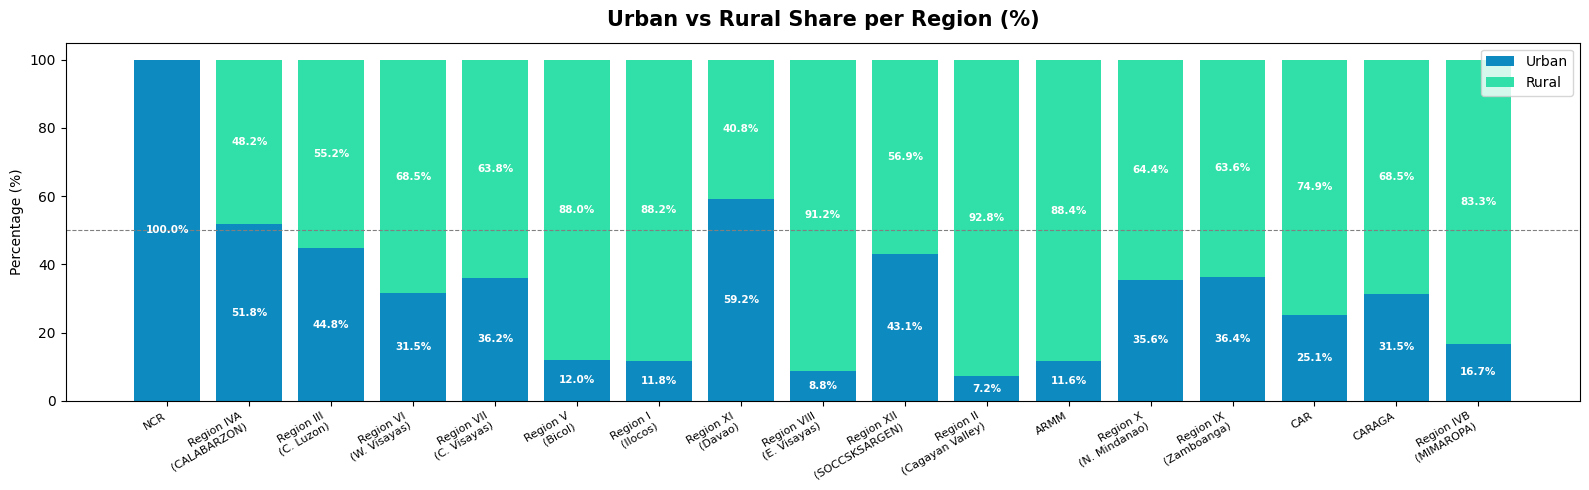


Region                             Urban   Rural   Total  %Urban  %Rural
────────────────────────────────────────────────────────────────────
NCR                                 4323       0    4323   100.0     0.0
Region IVA (CALABARZON)             2021    1884    3905    51.8    48.2
Region III (C. Luzon)               1413    1741    3154    44.8    55.2
Region VI (W. Visayas)               896    1945    2841    31.5    68.5
Region VII (C. Visayas)              915    1615    2530    36.2    63.8
Region V (Bicol)                     276    2017    2293    12.0    88.0
Region I (Ilocos)                    268    2002    2270    11.8    88.2
Region XI (Davao)                   1339     921    2260    59.2    40.8
Region VIII (E. Visayas)             190    1980    2170     8.8    91.2
Region XII (SOCCSKSARGEN)            882    1163    2045    43.1    56.9
Region II (Cagayan Valley)           147    1890    2037     7.2    92.8
ARMM                                 216    1648    18

In [112]:

# Plot 2: Stacked 100% bar — Urban/Rural proportion per region 
region_pct = region_urb[["Urban","Rural"]].div(region_urb["Total"], axis=0) * 100

fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(regions, region_pct["Urban"], label="Urban", color=urban_c)
ax.bar(regions, region_pct["Rural"], bottom=region_pct["Urban"], label="Rural", color=rural_c)

for i, r in enumerate(regions):
    u, ru = region_pct.loc[r,"Urban"], region_pct.loc[r,"Rural"]
    if u  >= 6: ax.text(i, u/2,    f"{u:.1f}%",  ha="center", va="center", fontsize=7.5, color="white", fontweight="bold")
    if ru >= 6: ax.text(i, u+ru/2, f"{ru:.1f}%", ha="center", va="center", fontsize=7.5, color="white", fontweight="bold")

ax.axhline(50, linestyle="--", color="gray", linewidth=0.8)
ax.set_title("Urban vs Rural Share per Region (%)", fontsize=15, fontweight="bold", pad=12)
ax.set_xticks(range(len(regions))); ax.set_xticklabels(regions, fontsize=8, rotation=30, ha="right")
ax.set_ylabel("Percentage (%)"); ax.set_ylim(0, 105)
ax.legend()
plt.tight_layout(); plt.show()

# Summary table
stats = region_urb.copy()
stats["% Urban"] = (stats["Urban"] / stats["Total"] * 100).round(1)
stats["% Rural"] = (stats["Rural"] / stats["Total"] * 100).round(1)
print(f"\n{'Region':<32} {'Urban':>7} {'Rural':>7} {'Total':>7} {'%Urban':>7} {'%Rural':>7}")
print("─" * 68)
for region, row in stats.iterrows():
    print(f"{region.replace(chr(10),' '):<32} {int(row.Urban):>7} {int(row.Rural):>7} {int(row.Total):>7} {row['% Urban']:>7.1f} {row['% Rural']:>7.1f}")
print("─" * 68)
tot = stats[["Urban","Rural","Total"]].sum()
print(f"{'TOTAL':<32} {int(tot.Urban):>7} {int(tot.Rural):>7} {int(tot.Total):>7} {tot.Urban/tot.Total*100:>7.1f} {tot.Rural/tot.Total*100:>7.1f}")


**Regional Distribution:**

The regional breakdown reveals stark geographic patterns in urbanization across the Philippines:

- **NCR is 100% Urban (4,323 households, 0 rural).** This is expected, the National Capital Region is the country's only purely urban administrative region.
- **CALABARZON (Region IVA) is the most balanced region** at 51.8% Urban vs 48.2% Rural, reflecting its role as a rapidly urbanizing region adjacent to Metro Manila with a mix of urban centers (Antipolo, Calamba, Dasmarinas) and rural municipalities.
- **Region XI (Davao) leans Urban at 59.2%**, consistent with Davao City's status as a major urban center in Mindanao.
- **Region III (Central Luzon) is 44.8% Urban**, reflecting the region's mix of highly urban cities (Angeles, San Fernando) and predominantly rural agricultural municipalities.
- **The most rural regions** are Region II (Cagayan Valley, 92.8% rural), Region VIII (Eastern Visayas, 91.2% rural), Region V (Bicol, 88.0% rural), Region I (Ilocos, 88.2% rural), and ARMM (88.4% rural), all of which are characterized by predominantly agricultural or island economies with limited urban development.
- **Overall, the dataset is 38.3% Urban and 61.7% Rural** (15,373 vs 24,798 households), confirming the class imbalance noted in the Basic Dataset Information section.

The wide variation in urban-rural composition across regions confirms that `W_REGN` is a highly informative feature. Regions with extreme compositions (NCR at 100% urban, Cagayan Valley at ~93% rural) provide very strong geographic classification signals.

#### Structural Feature Distributions: Urban vs Rural

Beyond income and geography, the physical structure of a household's dwelling is a direct reflection of its urban or rural setting. Urban homes are more likely to be made of strong, permanent materials and to be part of multi-unit or commercial buildings, while rural homes more commonly use light or salvaged materials. We visualize building type, roof material, and wall material distributions separately for urban and rural households to highlight these structural contrasts.

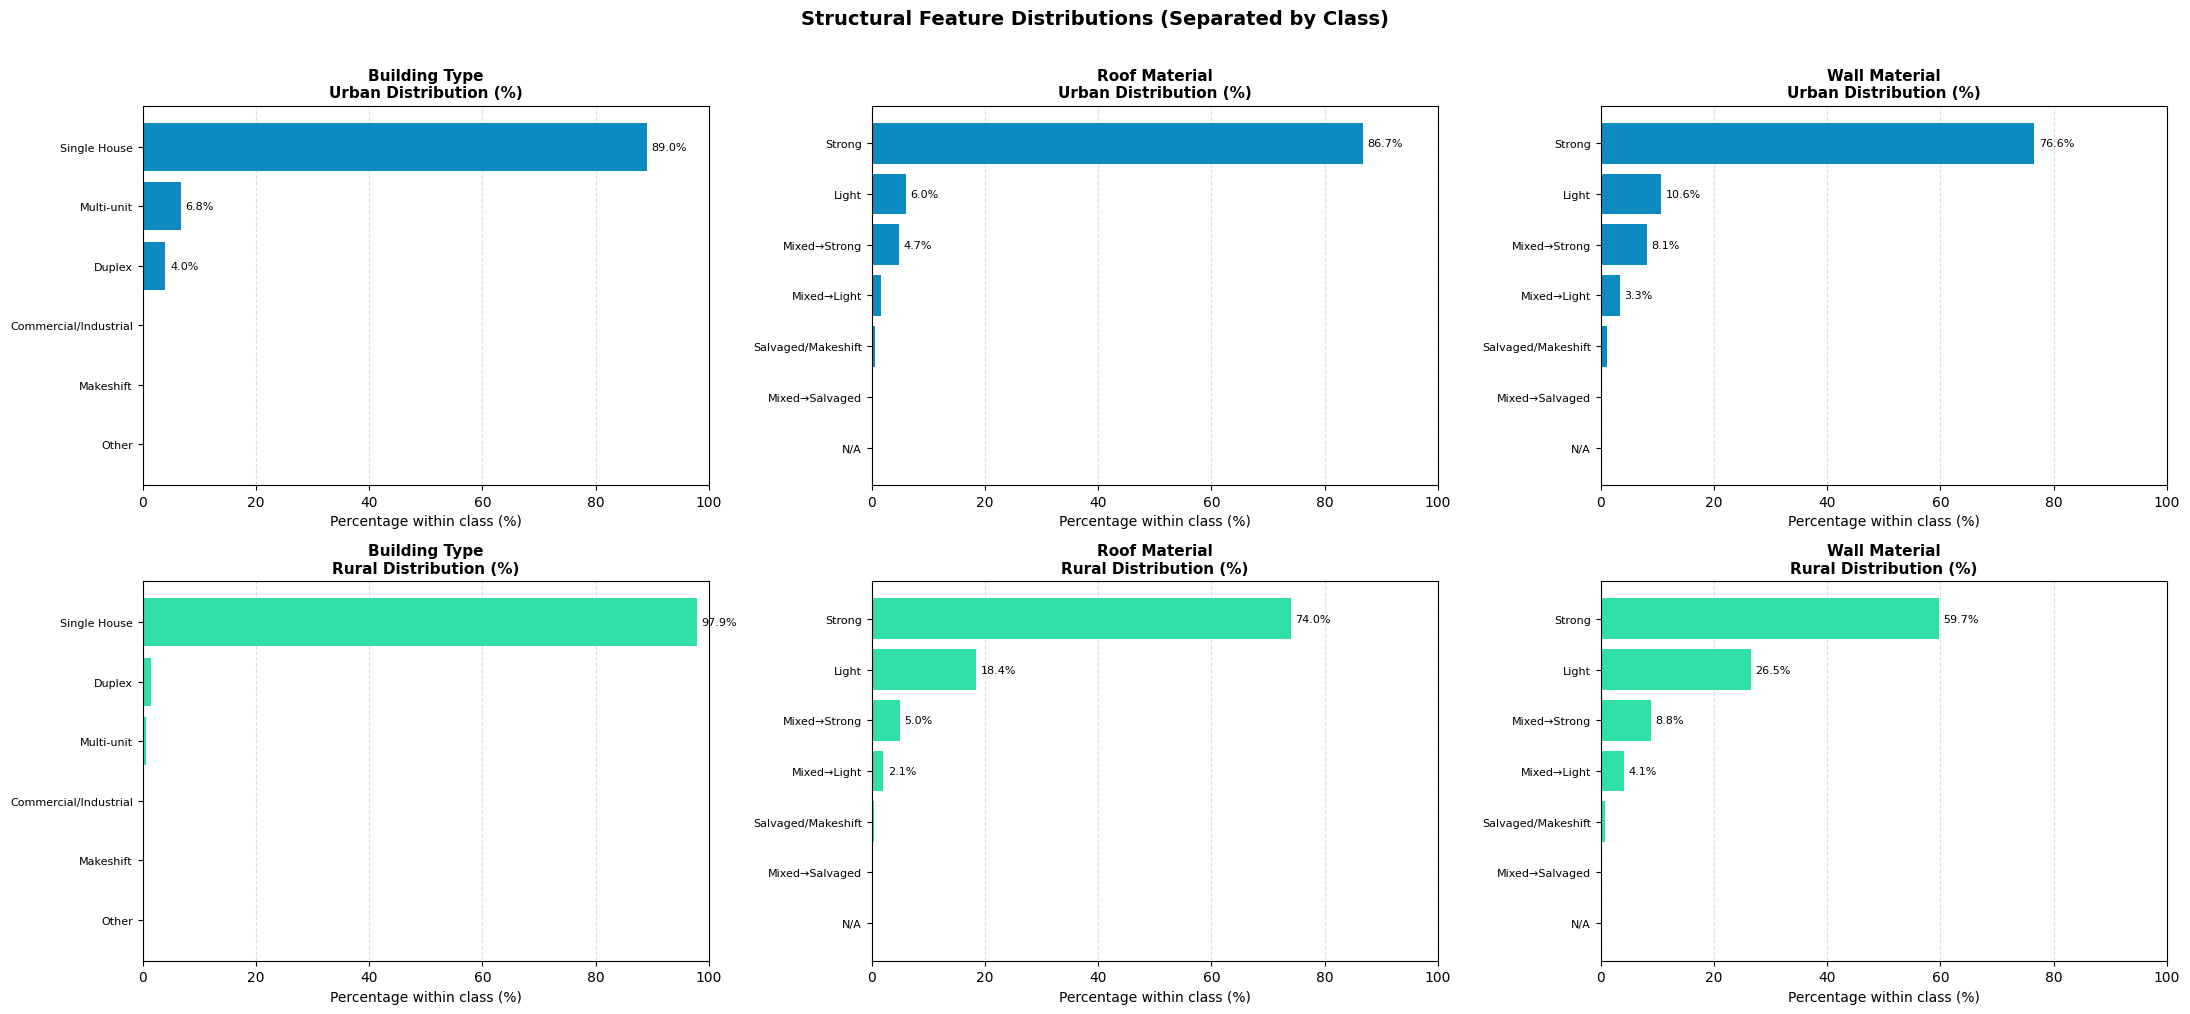

In [113]:

def stacked_pct_chart(ax, df, col, label_map, title, urb_col="URB_LABEL"):
    grouped = (
        df.groupby([col, urb_col])
        .size()
        .unstack(fill_value=0)
    )

    for c in ["Urban", "Rural"]:
        if c not in grouped:
            grouped[c] = 0

    grouped["Total"] = grouped["Urban"] + grouped["Rural"]
    grouped = grouped.sort_values("Total", ascending=True)
    grouped["Rural_prop"] = (grouped["Rural"] / sum(grouped["Rural"])) * 100
    grouped["Urban_prop"] = (grouped["Urban"] / sum(grouped["Urban"])) * 100
    grouped["Urban%"] = (grouped["Urban_prop"] / (grouped["Rural_prop"] + grouped["Urban_prop"])) * 100
    grouped["Rural%"] = (grouped["Rural_prop"] / (grouped["Rural_prop"] + grouped["Urban_prop"])) * 100

    labels = [label_map.get(idx, str(idx)) for idx in grouped.index]
    y = np.arange(len(labels))

    ax.barh(y, grouped["Urban%"], color=urban_c, label="Urban")
    ax.barh(y, grouped["Rural%"], left=grouped["Urban%"], color=rural_c, label="Rural")

    for i in range(len(y)):
        u, r = grouped["Urban%"].iloc[i], grouped["Rural%"].iloc[i]
        if u >= 8:
            ax.text(u / 2, i, f"{u:.1f}%", ha="center", va="center", fontsize=8, color="white", fontweight="bold")
        if r >= 8:
            ax.text(u + r / 2, i, f"{r:.1f}%", ha="center", va="center", fontsize=8, color="white", fontweight="bold")

    ax.axvline(50, color="gray", linestyle="--", linewidth=0.8)
    ax.set_yticks(y)
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlim(0, 100)
    ax.set_xlabel("Percentage (%)")
    ax.set_title(title, fontsize=12, fontweight="bold")


fig, axes = plt.subplots(2, 3, figsize=(22, 10), sharex=False)


plot_single_class_distribution(
    axes[0, 0], fies_subset_df_labeled, "BLDG_TYPE", BLDG_LABELS,
    class_label="Urban", color=urban_c,
    title="Building Type\nUrban Distribution (%)"
 )
plot_single_class_distribution(
    axes[0, 1], fies_subset_df_labeled, "ROOF", ROOF_LABELS,
    class_label="Urban", color=urban_c,
    title="Roof Material\nUrban Distribution (%)"
 )
plot_single_class_distribution(
    axes[0, 2], fies_subset_df_labeled, "WALLS", WALLS_LABELS,
    class_label="Urban", color=urban_c,
    title="Wall Material\nUrban Distribution (%)"
 )

plot_single_class_distribution(
    axes[1, 0], fies_subset_df_labeled, "BLDG_TYPE", BLDG_LABELS,
    class_label="Rural", color=rural_c,
    title="Building Type\nRural Distribution (%)"
 )
plot_single_class_distribution(
    axes[1, 1], fies_subset_df_labeled, "ROOF", ROOF_LABELS,
    class_label="Rural", color=rural_c,
    title="Roof Material\nRural Distribution (%)"
 )
plot_single_class_distribution(
    axes[1, 2], fies_subset_df_labeled, "WALLS", WALLS_LABELS,
    class_label="Rural", color=rural_c,
    title="Wall Material\nRural Distribution (%)"
 )

fig.suptitle(
    "Structural Feature Distributions (Separated by Class)",
    fontsize=14, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.show()


**Structural Feature Distributions:**

The side-by-side distributions for building type, roof material, and wall material reveal meaningful differences between urban and rural households:

**Building Type:**
- Urban households have a noticeably higher proportion of **Multi-unit residential buildings** (apartments, condominiums) compared to rural households, where multi-unit buildings are almost entirely absent. This directly reflects the density of urban housing.
- **Duplex** buildings also skew more urban.
- **Single House** dominates both classes (~94% overall), but its share is slightly higher in rural areas, where detached homes are the near-universal housing form.
- Makeshift structures are rare in both classes but slightly more represented in rural areas.

**Roof Material:**
- Both urban and rural households are dominated by **Strong roof materials**, but urban households have a higher concentration of strong roofs.
- **Light roof materials** are more concentrated among rural households, reflecting the use of traditional and locally sourced materials in rural construction.
- Mixed and salvaged roofing materials are rare but more prevalent in rural areas.

**Wall Material:**
- **Strong wall materials** are more common among urban households.
- **Light wall materials** are significantly more prevalent in rural households, representing the traditional bahay kubo construction style.
- Mixed-strong walls (category 4) are distributed across both classes, while mixed-light and salvaged walls lean rural.

Overall, the structural features confirm that urban households live in more permanently constructed, denser housing, while rural households more commonly use lighter, traditional building materials, providing meaningful signals for the classification models.

#### Amenity Distributions: Urban vs Rural

Access to basic amenities, sanitation, electricity, and clean water, is one of the starkest dividing lines between urban and rural households in the Philippines. Urban households are far more likely to have water-sealed toilets, electricity connections, and access to communal water systems, while rural households more commonly rely on pit latrines, open wells, springs, or rivers. We compare the distribution of toilet type, electricity access, and water source between the two classes.

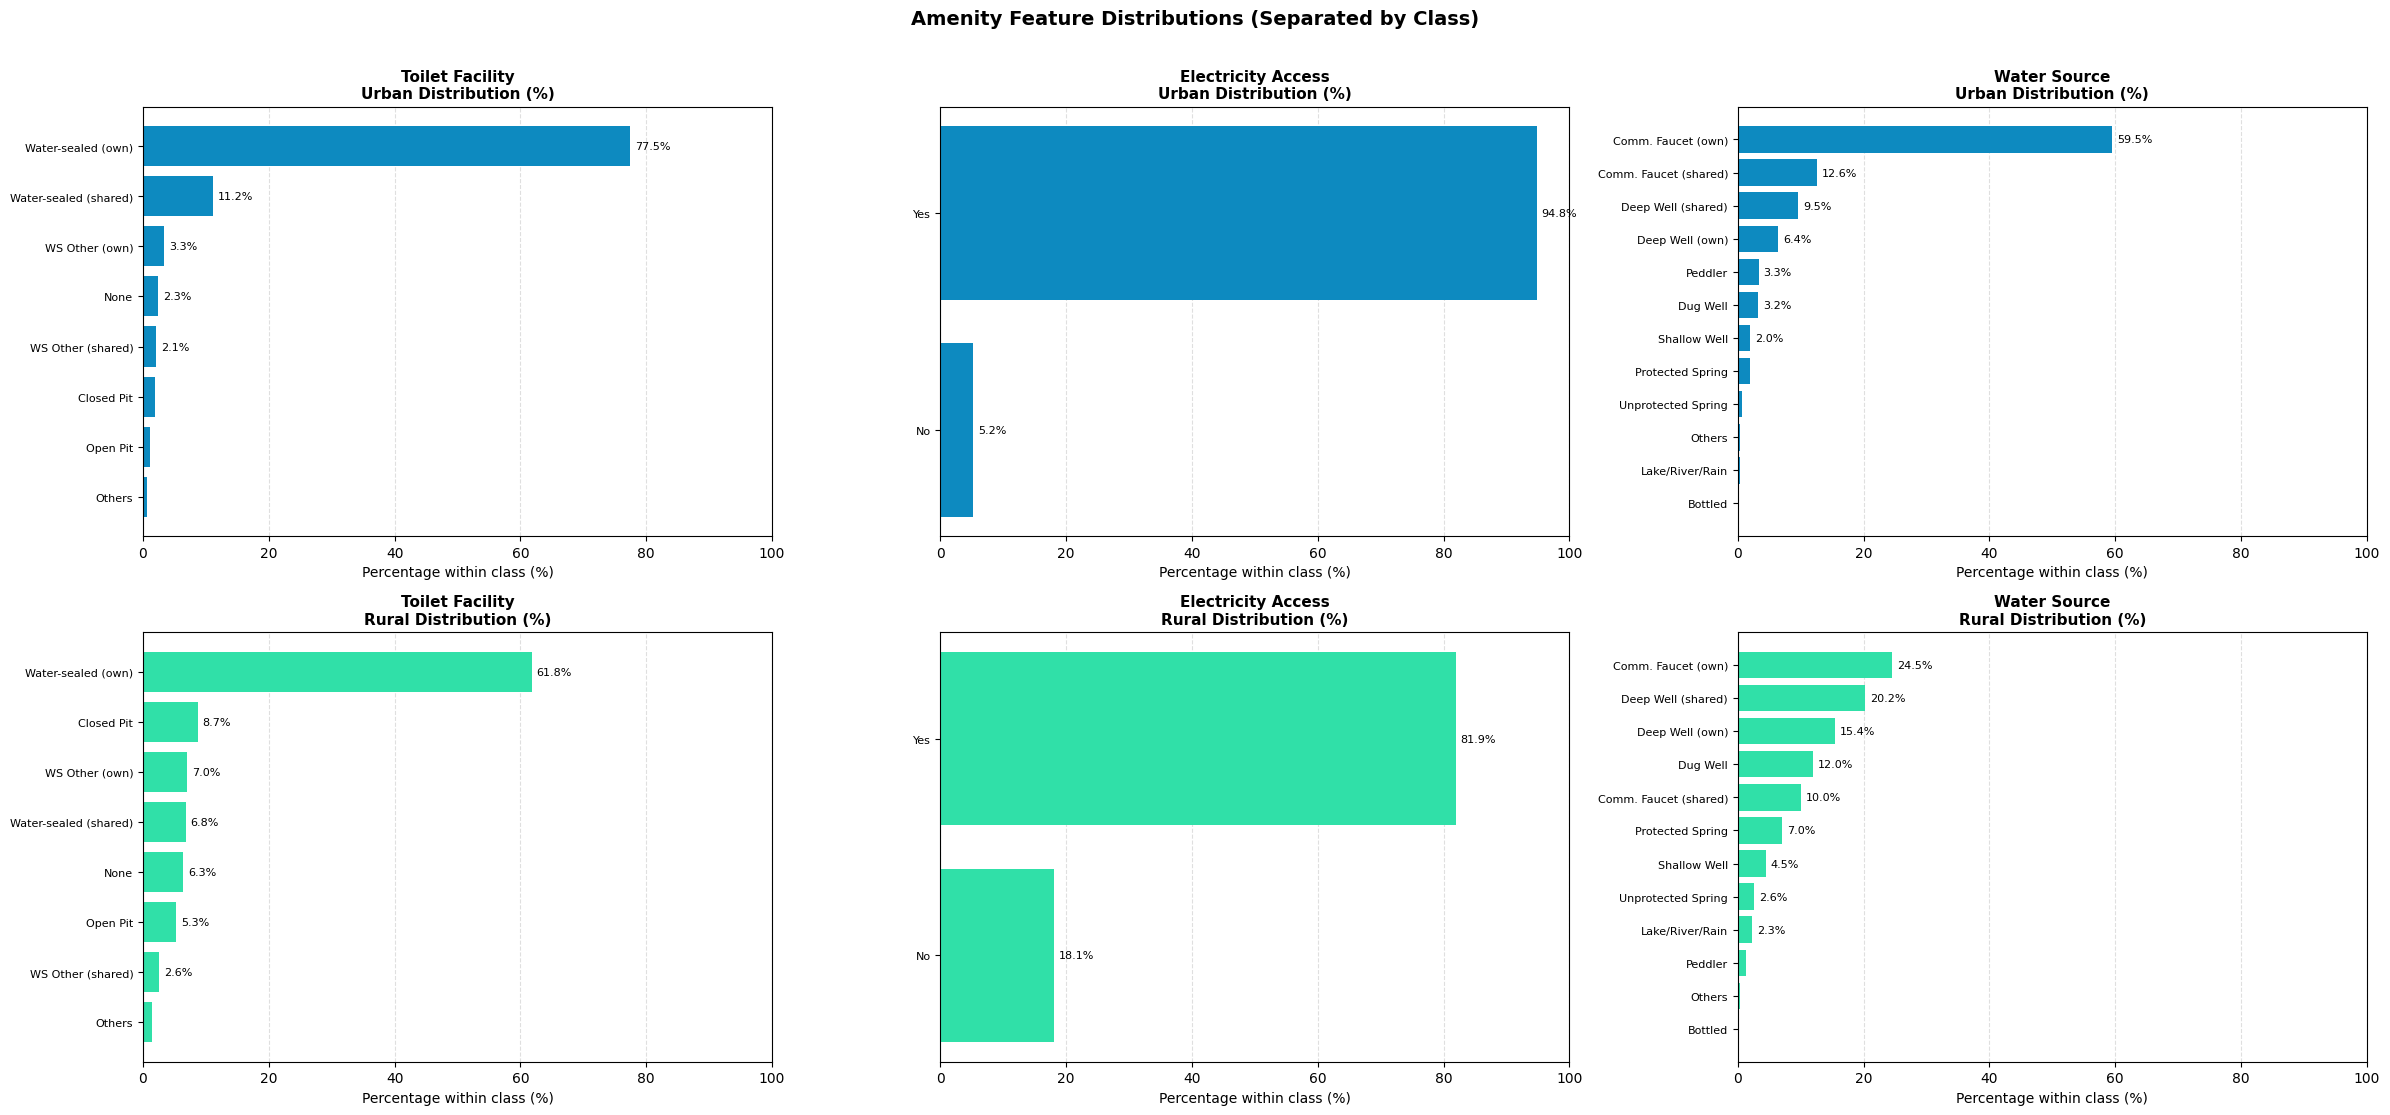

In [114]:

fig, axes = plt.subplots(2, 3, figsize=(24, 11), sharex=False)

plot_single_class_distribution(
    axes[0, 0], fies_subset_df_labeled, "TOILET", TOILET_LABELS,
    class_label="Urban", color=urban_c,
    title="Toilet Facility\nUrban Distribution (%)"
 )
plot_single_class_distribution(
    axes[0, 1], fies_subset_df_labeled, "ELECTRIC", ELECTRIC_LABELS,
    class_label="Urban", color=urban_c,
    title="Electricity Access\nUrban Distribution (%)"
 )
plot_single_class_distribution(
    axes[0, 2], fies_subset_df_labeled, "WATER", WATER_LABELS,
    class_label="Urban", color=urban_c,
    title="Water Source\nUrban Distribution (%)"
 )

plot_single_class_distribution(
    axes[1, 0], fies_subset_df_labeled, "TOILET", TOILET_LABELS,
    class_label="Rural", color=rural_c,
    title="Toilet Facility\nRural Distribution (%)"
 )
plot_single_class_distribution(
    axes[1, 1], fies_subset_df_labeled, "ELECTRIC", ELECTRIC_LABELS,
    class_label="Rural", color=rural_c,
    title="Electricity Access\nRural Distribution (%)"
 )
plot_single_class_distribution(
    axes[1, 2], fies_subset_df_labeled, "WATER", WATER_LABELS,
    class_label="Rural", color=rural_c,
    title="Water Source\nRural Distribution (%)"
 )

fig.suptitle(
    "Amenity Feature Distributions (Separated by Class)",
    fontsize=14, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.show()


**Amenity Feature Distributions:**

The amenity distributions reveal some of the starkest contrasts between urban and rural households in the dataset:

**Toilet Facility:**
- **Water-sealed (own)** toilets dominate urban households, accounting for the large majority of urban sanitation. This type of toilet requires plumbing infrastructure and a reliable water supply, both characteristics of urban areas.
- Rural households show a far more diverse distribution: while water-sealed toilets are also the most common type, a substantial proportion of rural households use **Closed Pit**, **Open Pit**, and **No toilet** options. These categories are almost entirely absent among urban households.
- **Water-sealed (shared)** toilets are more common in urban areas, reflecting shared sanitation in dense multi-unit buildings.

**Electricity Access:**
- The vast majority of urban households (**~95%**) have electricity access, making this a near-universal characteristic of urban living.
- Rural households show meaningful electricity non-access, approximately **18% of rural households lack electricity**, representing a genuine infrastructure gap. This makes `ELECTRIC` a useful but asymmetric feature: its absence is almost exclusively a rural signal.

**Water Source:**
- Urban households rely heavily on **Community Faucet (own connection)**, a piped water system, reflecting access to formal water utility networks.
- Rural households show a much more distributed water source profile: **Deep Well (shared and own)**, **Dug Well**, **Protected Spring**, and even **Lake/River/Rain** are all meaningfully represented. This diversity in rural water sourcing reflects the lack of centralized water infrastructure outside of urban centers.
- **Peddler water** (purchased from water vendors) is a small but notable rural category, reflecting areas without any piped or well access.

The amenity features, particularly toilet type and water source, provide strong classification signals because their distributions are highly asymmetric, certain categories (e.g., open pit toilets, river water) are essentially exclusive to rural households.

#### Appliance & Vehicle Ownership: Urban vs Rural

Ownership of household appliances and vehicles is a reliable proxy for both income level and urban infrastructure access. Items like air conditioners, personal computers, and landline phones are disproportionately concentrated in urban households, reflecting both higher purchasing power and the availability of reliable electricity and telecommunications networks. Motorcycles, by contrast, tend to be more common in rural areas as the primary mode of transport. We compare average ownership counts per household for each asset category.

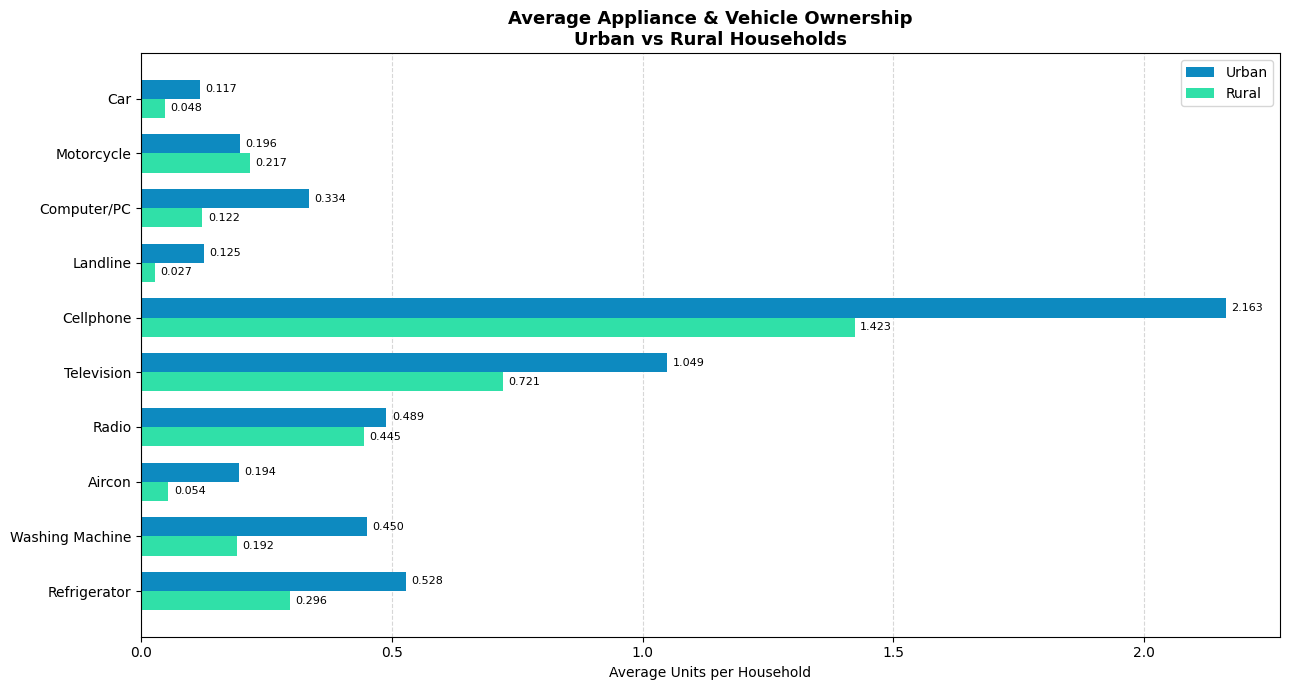

In [115]:

appliance_cols = {
    "CAR_QTY":        "Car",
    "MOTORCYCLE_QTY": "Motorcycle",
    "PC_QTY":         "Computer/PC",
    "LANDLINE_QTY":   "Landline",
    "CELLPHONE_QTY":  "Cellphone",
    "TV_QTY":         "Television",
    "RADIO_QTY":      "Radio",
    "AIRCON_QTY":     "Aircon",
    "WASH_QTY":       "Washing Machine",
    "REF_QTY":        "Refrigerator",
}

app_df = fies_subset_df_labeled[list(appliance_cols.keys()) + ["URB_LABEL"]].copy()
for col in appliance_cols:
    app_df[col] = pd.to_numeric(app_df[col], errors="coerce")

app_mean = (
    app_df
    .groupby("URB_LABEL")[list(appliance_cols.keys())]
    .mean()
    .rename(columns=appliance_cols)
    .T
)

n = len(app_mean)
y = np.arange(n)
bar_h = 0.35

fig, ax = plt.subplots(figsize=(13, 7))
b_u = ax.barh(y - bar_h/2, app_mean["Urban"], height=bar_h, label="Urban", color=urban_c)
b_r = ax.barh(y + bar_h/2, app_mean["Rural"],  height=bar_h, label="Rural",  color=rural_c)

ax.bar_label(b_u, padding=4, fmt="{:.3f}", fontsize=8)
ax.bar_label(b_r, padding=4, fmt="{:.3f}", fontsize=8)

ax.set_yticks(y); ax.set_yticklabels(app_mean.index, fontsize=10)
ax.invert_yaxis()
ax.set_xlabel("Average Units per Household")
ax.set_title("Average Appliance & Vehicle Ownership\nUrban vs Rural Households",
             fontsize=13, fontweight="bold")
ax.xaxis.grid(True, linestyle="--", alpha=0.5); ax.set_axisbelow(True)
ax.legend()
plt.tight_layout(); plt.show()


**Appliance & Vehicle Ownership:**

The average ownership chart reveals clear and consistent patterns in asset ownership between urban and rural households:

- **Air Conditioner** shows the largest relative gap, urban households own roughly 3–4× more air conditioners on average than rural households. Air conditioners require stable electricity supply, significant purchasing power, and are associated with a modern urban lifestyle. This makes it a strong urban signal.
- **Personal Computer (PC)** is significantly more common in urban households, reflecting higher disposable income, greater need for digital work and education, and better access to electronics retail.
- **Refrigerator and Washing Machine** are also substantially more prevalent in urban households, consistent with higher income and reliable electricity access.
- **Landline** phones are almost exclusively urban, which makes sense given the collapse of landline infrastructure in rural areas and the dominance of mobile-only connectivity outside cities.
- **Television** is relatively common in both classes (overall mean of ~0.85 per household), but urban households own slightly more on average. Its near-universal presence in both classes makes it a weaker differentiator.
- **Cellphone** is the most commonly owned asset in the dataset (mean of ~1.71) and is relatively similar across both urban and rural households, reflecting the broad penetration of mobile phones in the Philippines by 2012. This makes it one of the least discriminative asset features.
- **Radio** is also relatively common in both classes, consistent with its use as a primary information source in areas without reliable electricity or internet, and its declining relevance in urban areas where smartphones and internet have taken over.
- **Motorcycle** is slightly higher in rural areas, serving as a primary mode of transport in communities with limited public transit infrastructure. Cars, however, are more common in urban households, reflecting higher income and the practicality of car ownership in cities.

Overall, the asset ownership patterns reinforce the income and expenditure signals: urban households have greater access to durable goods and modern appliances, while rural households rely more on basic, lower-cost assets. These patterns will be picked up by the models as additional urbanization signals.

### **3.) Household Composition** 

Having examined urban-rural comparative statistics, we now look at the overall composition of the full dataset, regardless of class. This section summarizes the physical housing characteristics and asset ownership patterns across all households, giving us a sense of the dataset's baseline structure before any train-validation-test splitting occurs.

#### Household Physical Composition

We examine the value distributions of the six structural and amenity features: building type, roof material, wall material, toilet type, electricity access, and water source. The counts and proportions here show how the overall dataset is composed — including how dominated it is by the most common categories (e.g., single-house buildings and strong roof materials), which has implications for class balance and feature informativeness.

In [116]:
physical_features = ['BLDG_TYPE', 'ROOF', 'WALLS', 'TOILET', 'ELECTRIC', 'WATER']

# A. Statistical summaries
print("Physical Housing Composition Summaries")
for col in physical_features:
    if col in ws_or_na_df.columns:
        print(f"\nValue Counts for {col}:")
        print(ws_or_na_df[col].value_counts(normalize=True) * 100)

Physical Housing Composition Summaries

Value Counts for BLDG_TYPE:
BLDG_TYPE
1    94.503498
3     2.957357
2     2.392273
4     0.109532
5     0.027383
6     0.009957
Name: proportion, dtype: float64

Value Counts for ROOF:
ROOF
1    78.867840
2    13.698937
4     4.889099
5     1.924274
3     0.465510
6     0.144383
7     0.009957
Name: proportion, dtype: float64

Value Counts for WALLS:
WALLS
1    66.172114
2    20.407757
4     8.543477
5     3.778845
3     0.831446
6     0.253915
7     0.012447
Name: proportion, dtype: float64

Value Counts for TOILET:
TOILET
1    67.797665
2     8.466307
5     6.118842
3     5.588609
0     4.799482
6     3.689229
4     2.397252
7     1.142615
Name: proportion, dtype: float64

Value Counts for ELECTRIC:
ELECTRIC
1    86.843743
2    13.156257
Name: proportion, dtype: float64

Value Counts for WATER:
WATER
1     37.868114
4     16.118593
3     11.963855
2     11.030345
6      8.643051
7      5.060865
5      3.519952
10     2.068656
8      1.824699
9 

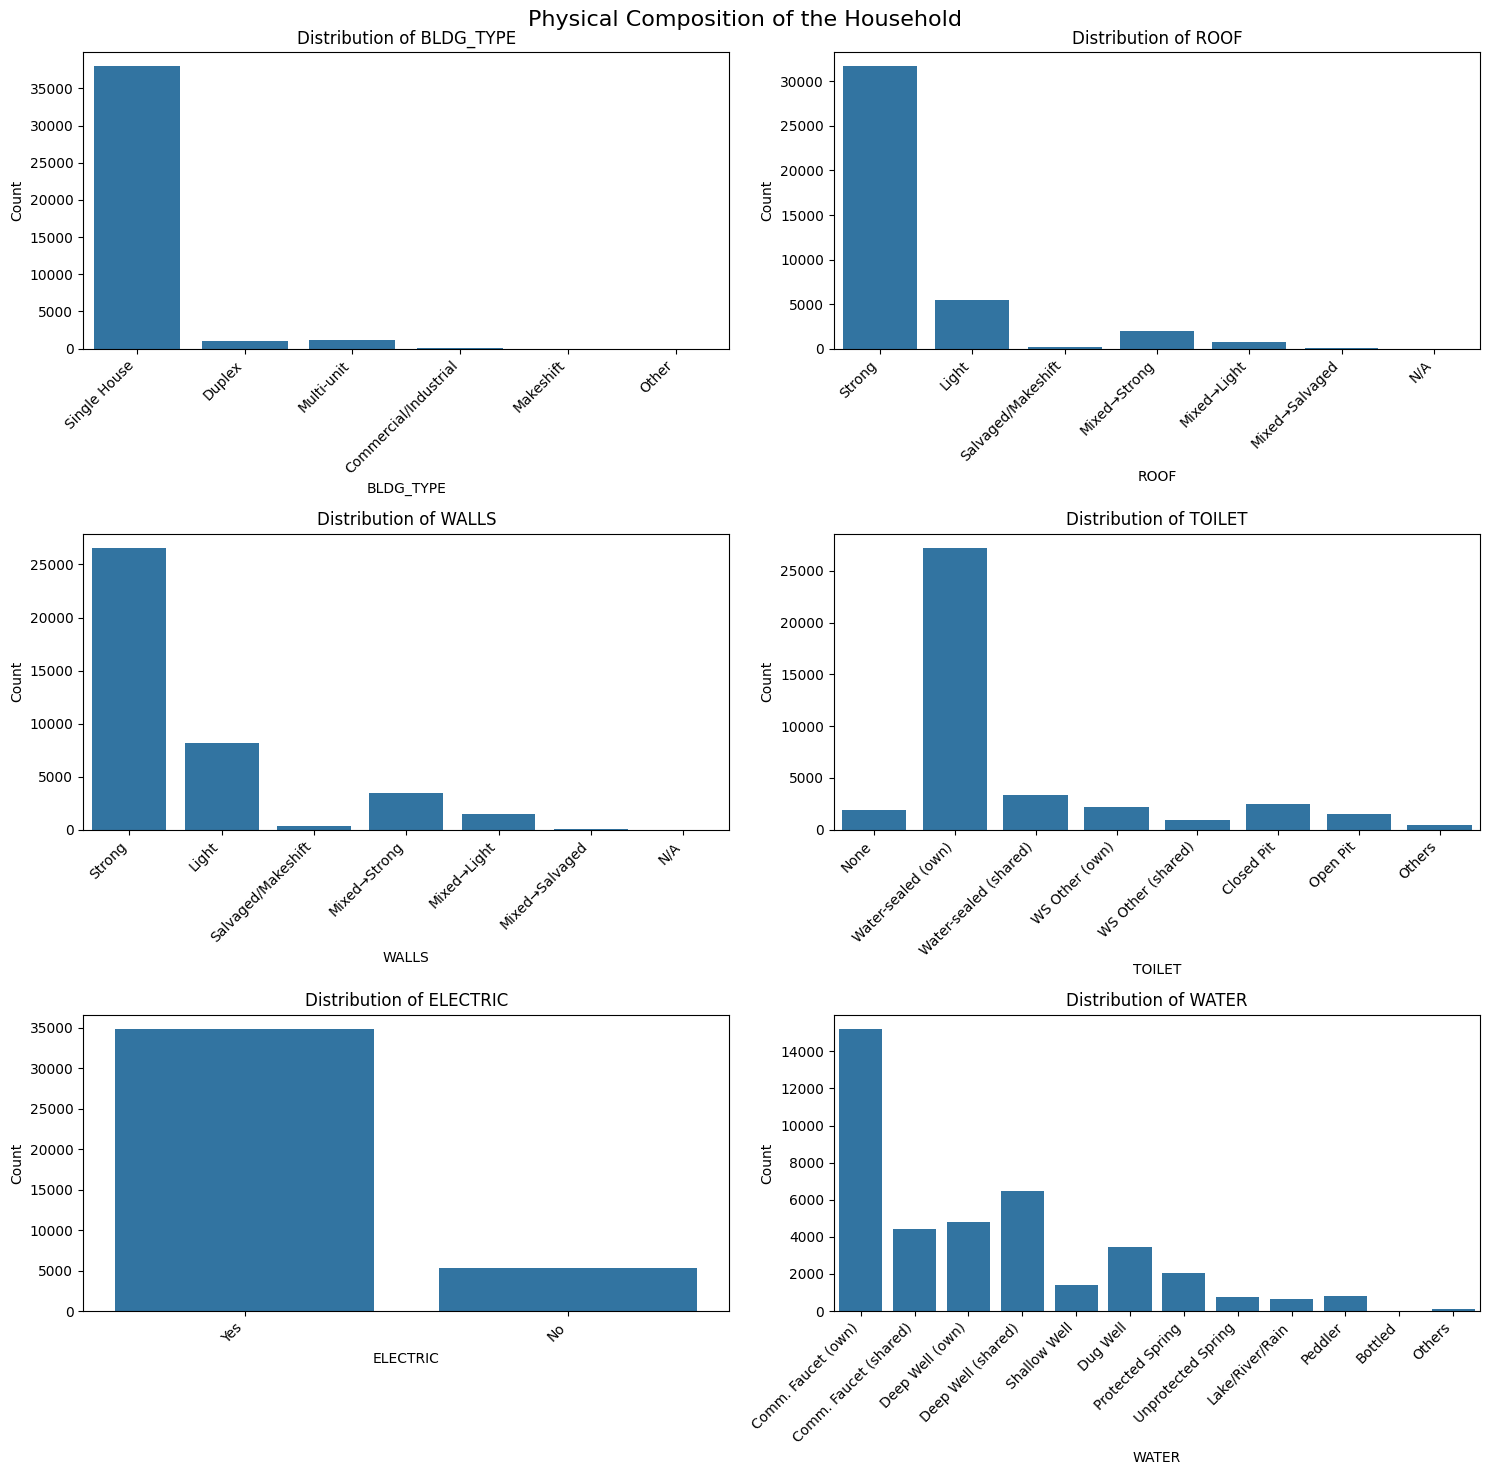

In [117]:
# B. Visualizing Physical Housing Composition (Categorical)
fig, axes = plt.subplots(3, 2, figsize=(15, 15))
fig.suptitle('Physical Composition of the Household', fontsize=16)

def set_xtick_labels(labels):
    ax.set_xticks([float(x) for x in range(0, len(labels))])
    ax.set_xticklabels(list(labels.values()), rotation=45, ha='right')

for i, col in enumerate(physical_features):
    if col in ws_or_na_df.columns:
        ax = axes[i//2, i%2]
        sns.countplot(data=ws_or_na_df, x=col, ax=ax)
        ax.set_title(f'Distribution of {col}')
        ax.tick_params(axis='x', rotation=45) 
        ax.set_ylabel('Count')

        if col=="BLDG_TYPE":
            set_xtick_labels(BLDG_LABELS)
        if col=="ROOF":
            set_xtick_labels(ROOF_LABELS)
        if col=="WALLS":
            set_xtick_labels(WALLS_LABELS)
        if col=="TOILET":
            set_xtick_labels(TOILET_LABELS)
        if col=="ELECTRIC":
            set_xtick_labels(ELECTRIC_LABELS)
        if col=="WATER":
            set_xtick_labels(WATER_LABELS)
        
plt.tight_layout()
plt.show()

**Physical Housing Composition (Full Dataset):**

The value counts across the full dataset (both classes combined) reinforce how dominant certain categories are:

- **Building Type:** 94.5% of all households live in Single Houses (Type 1). Multi-unit (2.96%) and Duplex (2.39%) together account for only ~5.4%, and Makeshift/Other types are negligible (<0.04%). The extreme dominance of single houses means this feature's discriminative power comes almost entirely from the small proportion of multi-unit and duplex buildings, which lean urban.
- **Roof Material:** Strong roofs account for 78.9% of all households, with Light roofs at 13.7% representing the second-largest category. Mixed-Strong (4.9%) and Mixed-Light (1.9%) make up most of the remainder. Salvaged and N/A categories are rare (<0.6% combined).
- **Wall Material:** Strong walls are present in 66.2% of households, with Light walls at 20.4% as the second-largest category. Mixed-Strong walls account for 8.5%. The higher proportion of light walls compared to light roofs suggests that households may upgrade their roofing before their walls, a common incremental construction pattern in the Philippines.
- **Toilet Facility:** Water-sealed (own) toilets are the most common at 67.8%, followed by Water-sealed (shared) at 8.5% and Closed Pit at 6.1%. The "No toilet" category accounts for 4.8% of households, which while small in proportion, represents roughly 1,930 households, primarily rural.
- **Electricity:** 86.8% of households have electricity access, with 13.2% lacking it. This confirms that non-electrification is a minority but non-trivial condition, almost entirely rural.
- **Water Source:** Community Faucet (own) is the dominant source at 37.9%, followed by Deep Well (shared) at 16.1% and Deep Well (own) at 12.0%. The wide variety of water sources, from piped connections to unprotected springs and rivers, reflects the infrastructure inequality across Philippine regions.

#### Household Asset Composition

We examine the distribution of asset ownership quantities across the dataset. Because most households own zero or one unit of most appliances, these distributions are heavily right-skewed. We use both summary statistics and boxplots to visualize the spread and identify extreme outliers (e.g., households reporting very high counts of a single asset), which may need to be handled during preprocessing.

In [118]:
asset_features = ['CAR_QTY', 'MOTORCYCLE_QTY', 'PC_QTY', 'LANDLINE_QTY', 'CELLPHONE_QTY', 
                  'TV_QTY', 'RADIO_QTY', 'AIRCON_QTY', 'WASH_QTY', 'REF_QTY']

# A. Statistical summaries
print("\nHousehold Asset Composition Summaries")
display(ws_or_na_df[asset_features].describe())


Household Asset Composition Summaries


,CAR_QTY,MOTORCYCLE_QTY,PC_QTY,LANDLINE_QTY,CELLPHONE_QTY,TV_QTY,RADIO_QTY,AIRCON_QTY,WASH_QTY,REF_QTY
count,40171.000000,40171.000000,40171.000000,40171.000000,40171.000000,40171.000000,40171.000000,40171.000000,40171.000000,40171.000000
mean,0.074332,0.209081,0.203306,0.064499,1.706082,0.846432,0.461701,0.107764,0.290682,0.384979
std,0.326798,0.487354,0.537806,0.279669,1.543661,0.654158,0.535887,0.410240,0.467002,0.535224
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,2.000000,1.000000,1.000000,0.000000,1.000000,1.000000
max,6.000000,11.000000,6.000000,5.000000,14.000000,7.000000,5.000000,8.000000,6.000000,5.000000


**Summary Statistics:**
- **Cellphone** is the only asset with a median > 0 (median = 1, mean = 1.71), confirming it as the most universally owned asset. Its maximum of 14 indicates some households with many members or significant resale activity, though such extreme values are rare.
- **Television** has a mean of 0.85 and median of 1, making it the second most commonly owned asset and one of the more uniformly distributed ones across the dataset.
- **All other assets** (Car, Motorcycle, PC, Landline, Aircon, Washing Machine, Refrigerator) have medians of 0 and 75th percentiles of 0, confirming that the majority of Philippine households in 2012 did not own these items.
- **Motorcycle** has the highest mean (0.21) among non-cellphone/TV assets, reflecting its importance as a transport vehicle particularly in rural areas.

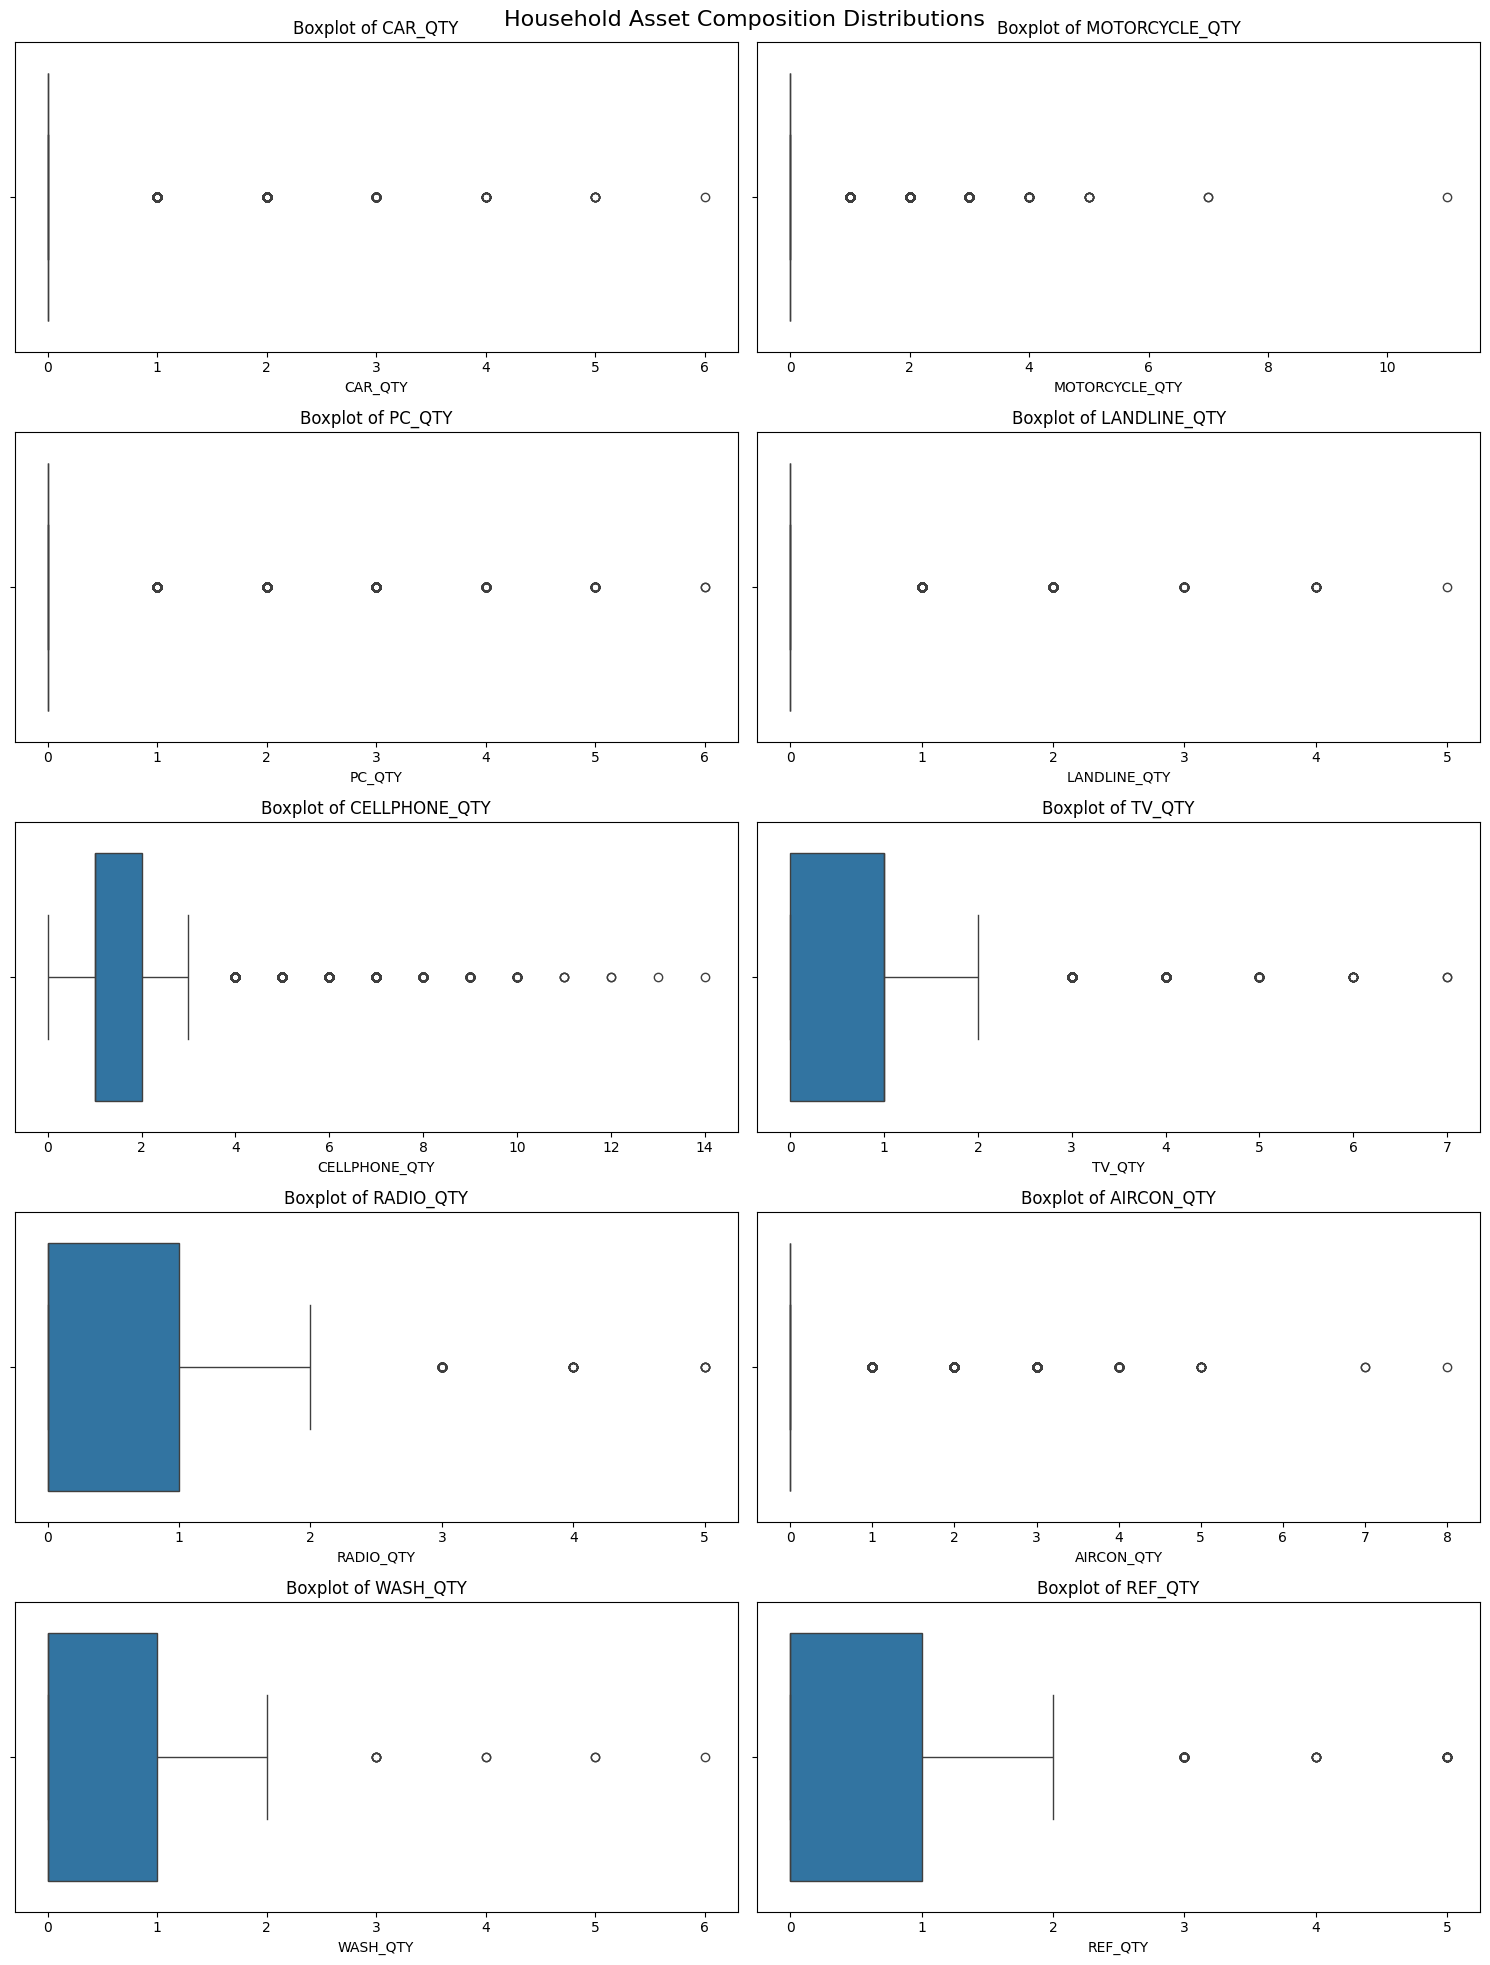

In [119]:
# B. Visualizing Asset/Appliance Quantities (Numerical)
fig, axes = plt.subplots(5, 2, figsize=(15, 20))
fig.suptitle('Household Asset Composition Distributions', fontsize=16)

for i, col in enumerate(asset_features):
    if col in ws_or_na_df.columns:
        ax = axes[i//2, i%2]

        # Using a boxplot to easily spot outliers
        sns.boxplot(data=ws_or_na_df, x=col, ax=ax)
        ax.set_title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

**Boxplot Distributions:**
- All asset distributions are heavily right-skewed with the central mass at zero and sparse but notable outliers. The boxplots confirm that for most assets, the interquartile range is [0, 0], with only the whiskers and outlier points showing non-zero values.
- Cellphones show the widest spread, with outliers extending to 14, while most other assets have outliers in the range of 3–8.
- These right-skewed, near-zero distributions motivate the use of **RobustScaler** during preprocessing, which scales based on the median and IQR rather than the mean, making it resistant to these outliers.

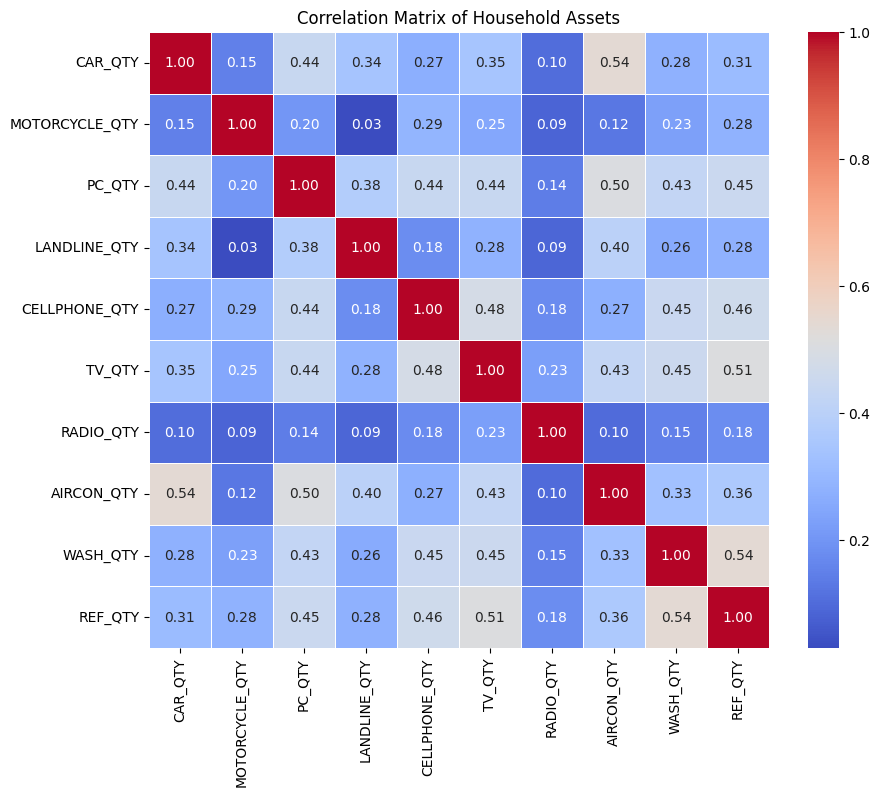

In [120]:
# C. Asset Correlation Heatmap 
# To see if owning certain items correlates with owning others
plt.figure(figsize=(10, 8))

# Coercing errors to NaN due to non-numeric entries (should we move this earlier?)
df_assets_numeric = ws_or_na_df[asset_features].apply(pd.to_numeric, errors='coerce')

correlation_matrix = df_assets_numeric.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Household Assets')
plt.show()

**Asset Correlation Heatmap:**
- Most asset pairs show **low to moderate positive correlations**, ranging from ~0.05 to ~0.30. This is expected, wealthier households tend to own more of everything, creating a mild wealth-driven correlation across all asset types.
- The strongest correlations are between **Refrigerator–Washing Machine** (~0.54), **Refrigerator–TV** (~0.51), and **Washing Machine–TV** (~0.45), suggesting that these three appliances tend to be acquired together as a household reaches a moderate income threshold.
- **Radio** is notably weakly correlated with most other assets (correlations mostly ~0.09–0.23), consistent with it being a low-cost, basic item owned across all income levels rather than a luxury good.
- **Car** shows relatively higher correlation with Aircon, PC, and Landline, forming a cluster of "premium" urban assets, consistent with the urban concentration of these items seen in the comparative charts.

# **[3]** Data Preprocessing
In this phase, we will prepare our dataset for the machine learning models. This involves converting our target variable to a standard binary format, testing and handling of outliers, handling nominal categorical variables through One-Hot Encoding, splitting the data into training, validation, and test sets to prevent data leakage, and standardizing our numerical features.

### 1. Target Variable Encoding
Currently, our target variable `URB` is encoded as `1` for Urban and `2` for Rural. Supervised machine learning algorithms generally expect binary classification targets to be represented as `0` and `1`. We will remap the Rural category from `2` to `0`.

In [121]:
# Map URB: 1 remains 1 (Urban), 2 becomes 0 (Rural)
fies_subset_df['URB'] = fies_subset_df['URB'].replace(2, 0)

# Verify the changes
print("Target Variable Distribution (1 = Urban, 0 = Rural):")
print(fies_subset_df['URB'].value_counts())

Target Variable Distribution (1 = Urban, 0 = Rural):
URB
0    24798
1    15373
Name: count, dtype: int64


### 2. Train-Validation-Test Split
To avoid data leakage, we must ensure proper training-validation-test splits.
* **Training Set (70%):** Used to train our classical models and neural network.
* **Validation Set (15%):** Used to tune hyperparameters and evaluate the models during training.
* **Test Set (15%):** Used for the final, unbiased evaluation of our models.

We will use the `stratify` parameter to ensure the proportion of Urban and Rural households remains perfectly balanced across all three splits.

In [122]:
# Separate Features (X) and Target (y)
X = fies_subset_df.drop('URB', axis=1)
y = fies_subset_df['URB']

# First split: 70% Train, 30% Temporary (which will become Val and Test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Second split: Divide the 30% Temporary set equally into 15% Validation and 15% Test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")

Training set: 28119 samples
Validation set: 6026 samples
Testing set: 6026 samples


### 3. Feature Selection
To reduce noise and prevent overfitting, we evaluate the statistical significance of our features. To strictly prevent data leakage, all statistical tests (T-tests, Chi-Square, and Mutual Information) are calculated using **only the Training Set (`X_train` and `y_train`)**. The validation and test sets are kept entirely blind during this decision-making process. 

First, we will perform **T-tests** to compare the means of our numerical features between urban and rural households. If a numerical feature is found to be not significantly different between classes, then it may not be useful in training the machine learning models to distinguish them, and must therefore be dropped.

In [123]:
from scipy.stats import ttest_ind

t_test_results = {}

# List of categorical features to avoid performing t-tests on (since t-tests are for numerical data)
categorical_features = ['W_REGN', 'BLDG_TYPE', 'ROOF', 'WALLS', 'TOILET', 'ELECTRIC', 'WATER']

# Skip categorical features and only perform t-tests on numerical features
for col in X_train.columns: 
    if col not in categorical_features:
        # Filter using y_train, extract the column from X_train
        urban_values = X_train[y_train == 1][col].dropna()
        rural_values = X_train[y_train == 0][col].dropna() 
        
        if len(urban_values) > 1 and len(rural_values) > 1: 
            stat, p_value = ttest_ind(urban_values, rural_values, equal_var=False)
            t_test_results[col] = (stat, p_value)
        else:
            print(f"{col}: Not enough data for t-test")

t_test_results_df = pd.DataFrame.from_dict(t_test_results, orient='index', columns=['t_statistic', 'p_value'])
t_test_results_df['significant'] = t_test_results_df['p_value'] < 0.05

t_test_results_df

,t_statistic,p_value,significant
NET_RECEIPT,-62.731208,0.000000e+00,True
REGFT,3.685075,2.292846e-04,True
EAINC,4.273423,1.936027e-05,True
TOINC,38.816480,0.000000e+00,True
T_FOOD_HOME,37.153171,1.250378e-291,True
T_FOOD,48.550793,0.000000e+00,True
T_CLOTH,24.570944,7.495632e-131,True
T_HEALTH,9.302514,1.533024e-20,True
T_HOUSING_WATER,49.894550,0.000000e+00,True
T_RENTVAL,43.352495,0.000000e+00,True


Next, because our target variable (`URB`) is categorical, we will use the **Chi-Squared test for independence** to evaluate the statistical significance of the categorical features (e.g., Roof Type, Water Source) in our training data. Features found to be independent of the target variable will also need to be dropped.

In [124]:
from scipy.stats import chi2_contingency

chi2_results = {}

for col in categorical_features:
    if col in X_train.columns:
        # Crosstab uses y_train against the categorical column in X_train
        contingency_table = pd.crosstab(y_train, X_train[col])
        chi2, p, dof, expected = chi2_contingency(contingency_table)
        chi2_results[col] = (chi2, p)

chi2_results_df = pd.DataFrame.from_dict(chi2_results, orient='index', columns=['chi2_statistic', 'p_value'])
chi2_results_df['significant'] = chi2_results_df['p_value'] < 0.05

chi2_results_df

,chi2_statistic,p_value,significant
W_REGN,8231.611323,0.000000e+00,True
BLDG_TYPE,1197.084082,1.257732e-256,True
ROOF,896.516296,2.127767e-190,True
WALLS,1132.510652,1.927370e-241,True
TOILET,1667.109488,0.000000e+00,True
ELECTRIC,976.450080,2.361732e-214,True
WATER,4691.914580,0.000000e+00,True


Although features may be considered significant in the T-tests and Chi-Squared tests, these methods only capture simple, isolated relationships and were only used for initial screening. Thus, we follow up with computing the **Mutual Information (MI)** scores, which can measure the overall dependency between each feature and the target variable. A value of zero indicates independence, and higher scores indicate greater dependency.

https://www.blog.trainindata.com/mutual-information-with-python/  
https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.mutual_info_classif.html

We will plot these scores to visually identify an "elbow", a threshold where the predictive power of the remaining features becomes negligible.

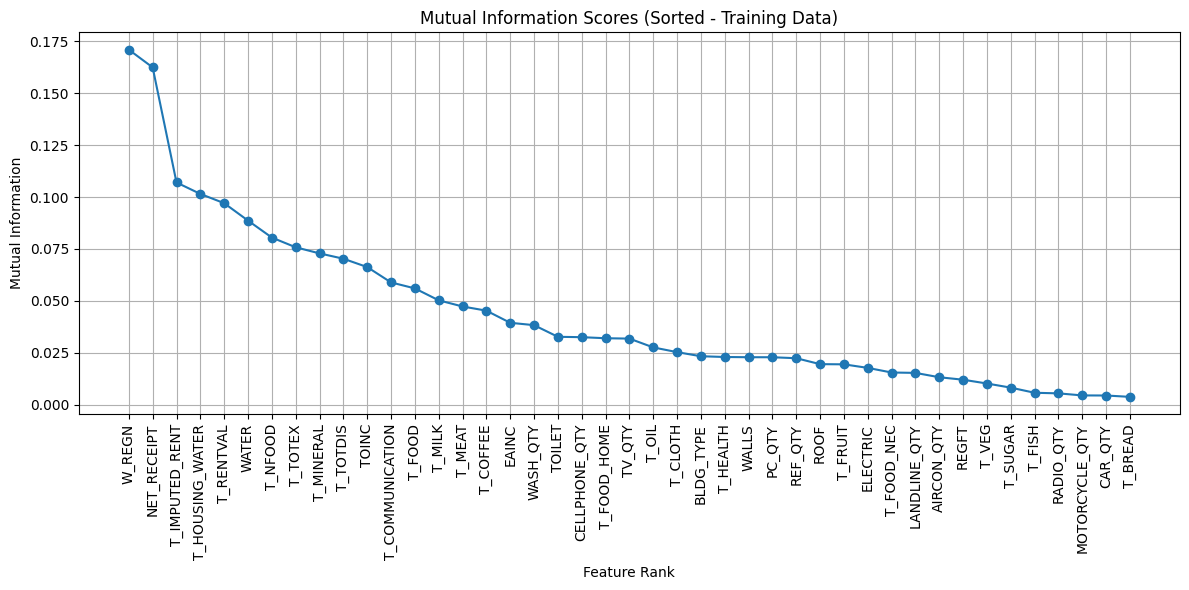

In [125]:
from sklearn.feature_selection import mutual_info_classif

# Compute mutual information scores
mi_scores = mutual_info_classif(X_train.fillna(0), y_train, random_state=0)
mi_scores_series = pd.Series(mi_scores, index=X_train.columns).sort_values(ascending=False)

# Sort scores from highest to lowest
mi_sorted = mi_scores_series.sort_values(ascending=False)

# Graph MI score for each feature, from most to least significant in an attempt to find an "elbow"
plt.figure(figsize=(12, 6))
plt.plot(range(len(mi_sorted)), mi_sorted.values, marker='o')
plt.title("Mutual Information Scores (Sorted - Training Data)")
plt.xlabel("Feature Rank")
plt.ylabel("Mutual Information")
plt.xticks(range(len(mi_sorted)), mi_sorted.index, rotation=90)
plt.grid(True)
plt.tight_layout()
plt.show()

Based on the Mutual Information graph generated from our training data, we have set a dropping threshold of `0.005`. 

To prevent a shape mismatch error during Model Training, the features identified as irrelevant must be removed across the board. We will now drop these specific columns from the Training, Validation, and Test sets simultaneously.

In [126]:
# Features with MI less than this will be dropped
threshold_for_dropping = 0.005

# Determine features to drop
features_to_drop = mi_scores_series[mi_scores_series < threshold_for_dropping].index

# Drop these features from Train, Validation, AND Test sets
X_train = X_train.drop(columns=features_to_drop)
X_val = X_val.drop(columns=features_to_drop)
X_test = X_test.drop(columns=features_to_drop)

print(f"Dropped {len(features_to_drop)} features.")
print(f"Remaining features for modeling: {X_train.shape[1]}")

Dropped 3 features.
Remaining features for modeling: 40


### 4. Handling Extreme Outliers (Log Transformation)
Financial features such as income (`Toinc`) and total expenditures (`T_TOTEX`) are highly right-skewed, meaning a small number of extremely wealthy households act as massive outliers. These extreme values can prevent our classical models and neural networks from learning effectively. 

To determine if our continuous financial features require transformation before modeling, we will visualize the distribution of Total Income (`TOINC`) and Total Expenditures (`T_TOTEX`).

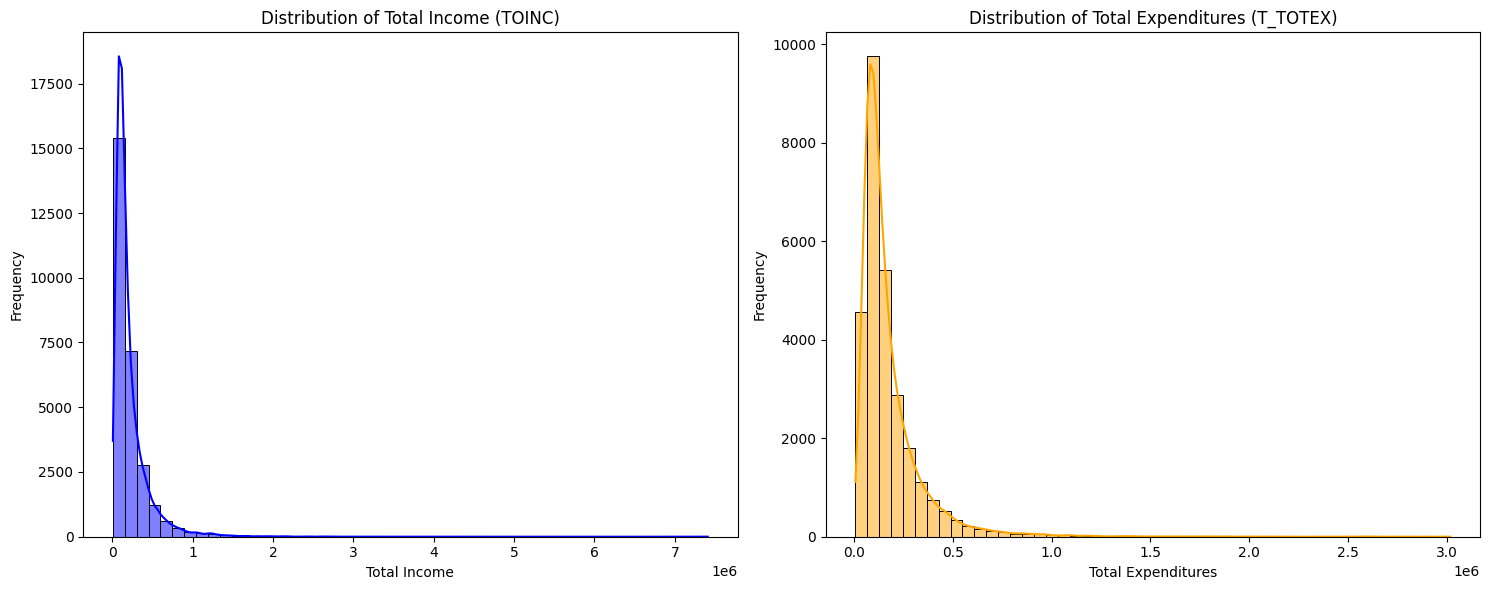

In [127]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Safely check if the columns survived feature selection before plotting
if 'TOINC' in X_train.columns:
    sns.histplot(X_train['TOINC'], bins=50, kde=True, ax=axes[0], color='blue')
    axes[0].set_title('Distribution of Total Income (TOINC)')
    axes[0].set_xlabel('Total Income')
    axes[0].set_ylabel('Frequency')

if 'T_TOTEX' in X_train.columns:
    sns.histplot(X_train['T_TOTEX'], bins=50, kde=True, ax=axes[1], color='orange')
    axes[1].set_title('Distribution of Total Expenditures (T_TOTEX)')
    axes[1].set_xlabel('Total Expenditures')
    axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

Instead of dropping these valid data points, we will apply a Logarithmic Transformation (`np.log1p`) to all financial columns. This mathematical transformation pulls extreme values closer to the median, creating a more normalized, "bell-shaped" distribution that machine learning algorithms handle much better. We use `log1p` (which calculates $log(1+x)$) to avoid errors when taking the log of a feature with a value of exactly 0.

In [128]:
# Isolate the financial columns (Income and Expenditures)
# We exclude 'TOILET' just in case the string matcher accidentally catches it
financial_cols = [
    col for col in X_train.columns 
    if col.startswith(('T_', 'NET_', 'REGFT', 'EAINC', 'TOINC')) and col != 'TOILET'
]

# Apply log1p transformation to ALL THREE datasets
for col in financial_cols:
    X_train[col] = np.log1p(X_train[col])
    X_val[col] = np.log1p(X_val[col])
    X_test[col] = np.log1p(X_test[col])

Now let us check the new distribution and determine if Total Income (`TOINC`) and Total Expenditures (`T_TOTEX`) are still skewed.

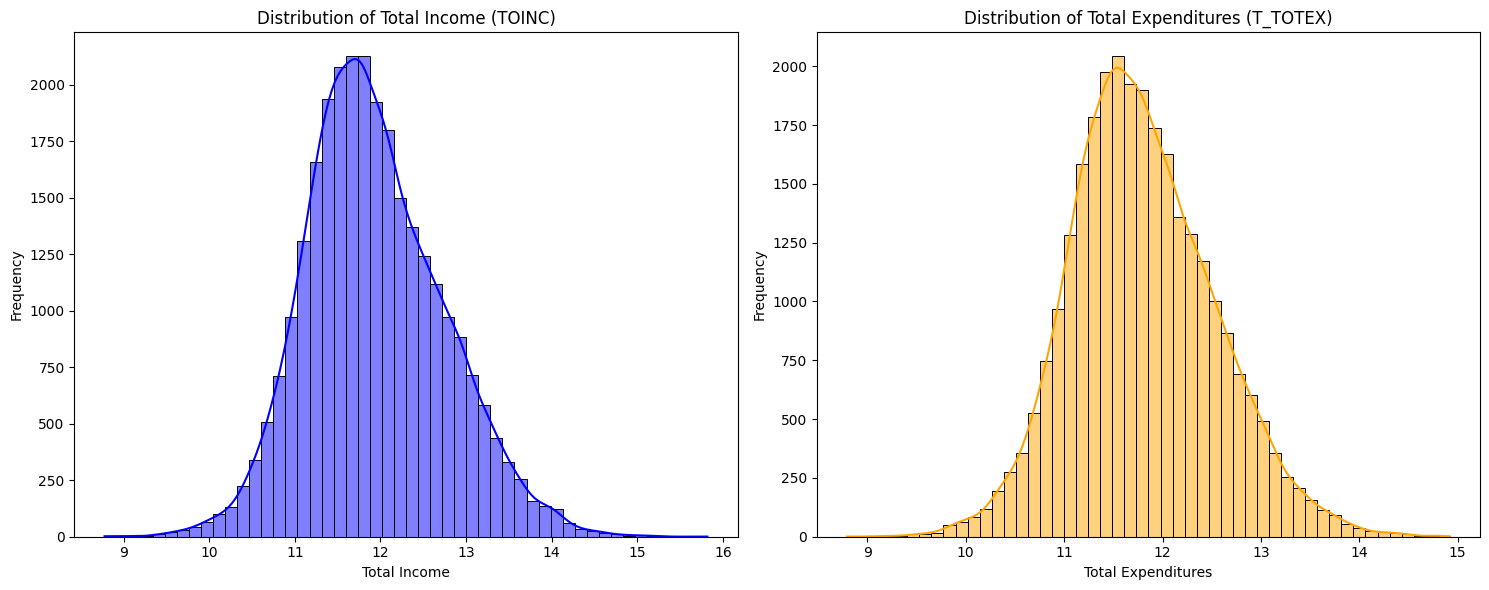

In [129]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Safely check if the columns survived feature selection before plotting
if 'TOINC' in X_train.columns:
    sns.histplot(X_train['TOINC'], bins=50, kde=True, ax=axes[0], color='blue')
    axes[0].set_title('Distribution of Total Income (TOINC)')
    axes[0].set_xlabel('Total Income')
    axes[0].set_ylabel('Frequency')

if 'T_TOTEX' in X_train.columns:
    sns.histplot(X_train['T_TOTEX'], bins=50, kde=True, ax=axes[1], color='orange')
    axes[1].set_title('Distribution of Total Expenditures (T_TOTEX)')
    axes[1].set_xlabel('Total Expenditures')
    axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### 5. One-Hot Encoding Categorical Features
Our dataset contains several nominal categorical features: `W_REGN`, `BLDG_TYPE`, `ROOF`, `WALLS`, `TOILET`, `ELECTRIC`, and `WATER`. Leaving these as arbitrary numbers might cause algorithms to incorrectly assume they have a mathematical hierarchy (e.g., Region 5 is "greater" than Region 2). 

To fix this, we apply One-Hot Encoding to convert them into binary indicator variables. We also use `drop_first=True` to drop the first category of each feature. This prevents multicollinearity (the "dummy variable trap"), which is highly beneficial for classical machine learning models like Logistic Regression.

In [130]:
# Define categorical columns
categorical_cols = ['W_REGN', 'BLDG_TYPE', 'ROOF', 'WALLS', 'TOILET', 'ELECTRIC', 'WATER']

# Ensure that we only encode columns that are still present after feature selection
cols_to_encode = [col for col in categorical_cols if col in X_train.columns]

# Check the old shape of the dataset
print(f"Original subset shape: {X_train.shape}")

X_train = pd.get_dummies(X_train, columns=cols_to_encode, drop_first=True)
X_val = pd.get_dummies(X_val, columns=cols_to_encode, drop_first=True)
X_test = pd.get_dummies(X_test, columns=cols_to_encode, drop_first=True)

# Align columns in case some categories only existed in the training set
X_val = X_val.reindex(columns=X_train.columns, fill_value=0)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# Check the new shape of the dataset
print(f"Encoded dataset shape: {X_train.shape}")

Original subset shape: (28119, 40)
Encoded dataset shape: (28119, 85)


### 6. Feature Scaling (Using RobustScaler)
Our features operate on vastly different scales. While our financial features have been log-transformed, our asset counts (like `CAR_QTY`) still range from 0 to 5, and our One-Hot Encoded variables are binary (0 or 1). 

Machine learning algorithms—especially Neural Networks and distance-based classical models—require features to be on a similar scale to converge properly. Because we still have some lingering outliers even after the log transformation, we will use `RobustScaler` instead of `StandardScaler`. `RobustScaler` scales the data using the median and the Interquartile Range (IQR), making it completely immune to extreme outliers.

**Important Data Leakage Prevention:** The scaler must be fitted *only* on the training data. We then apply that learned transformation to the validation and test sets.

In [131]:
# Initialize the RobustScaler
scaler = RobustScaler()

# Fit the scaler ONLY on the training data, then transform it
X_train_scaled = scaler.fit_transform(X_train)

# Transform the validation and test sets using the previously fitted scaler
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Convert the scaled arrays back to DataFrames to retain column names
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_train.columns)

To ensure strict consistency across all our machine learning models and to prevent accidental data leakage, we have centralized our data preprocessing in this notebook. 

Below, we export our final, robustly scaled training, validation, and test sets using the `joblib` library. Our individual model notebooks (Random Forest, Logistic Regression, Gradient Boosting, and MLP) will load these exact files. This guarantees that every algorithm in our project is trained, tuned, and evaluated on the exact same data splits.

In [132]:
import joblib
import os

os.makedirs('processed_data', exist_ok=True)

# Export the feature sets
joblib.dump(X_train_scaled, 'processed_data/X_train_scaled.pkl')
joblib.dump(X_val_scaled, 'processed_data/X_val_scaled.pkl')
joblib.dump(X_test_scaled, 'processed_data/X_test_scaled.pkl')

# Export the target variables
joblib.dump(y_train, 'processed_data/y_train.pkl')
joblib.dump(y_val, 'processed_data/y_val.pkl')
joblib.dump(y_test, 'processed_data/y_test.pkl')

['processed_data/y_test.pkl']